# Experiment 2026-07-13 — exploration length by propagation model

**Primary question:** how many early campaigns should be assigned to exploration before switching to exploitation, and does that choice depend on the true propagation model?

The notebook is deliberately decision-first. After the experiment runs, look at **Results at a glance** before the optional diagnostics.

Main outputs:

1. paired gain of each exploration count relative to \(k=0\);
2. best \(k\) for every propagation model and identifier;
3. sensitivity to choosing a non-optimal \(k\);
4. raw performance curves with confidence intervals.

The default study enables linear consensus, COCA, and Hegselmann--Krause. To run every implemented propagation model, set `RUN_ALL_IMPLEMENTED_DYNAMICS = True` in the configuration cell. To choose a custom subset, edit the single `ENABLED_DYNAMICS` list.

**Identifier paths used here:** the nonlinear online policy uses `opinion_dynamics.identify_nonlinear.GraphIdentifierEnv`; the linear comparison uses the notebook-local `PaperLinearGraphIdentifier`. The legacy `opinion_dynamics.identify` module is not used by this notebook.


This revision makes quick mode a strict subset of full mode, so cached quick-run trials are reused when expanding the replication grid.

**Cache maintenance:** changing propagation parameters produces new trial hashes,
so old trials are never mixed with current results. A dedicated cache
administration section can preview and archive stale trials per propagation
model.


## Windows-safe cache recovery

This revision avoids directory-level cache renames on Windows. It commits individual files and writes `manifest.json` last. Complete `.tmp` cache entries left by an interrupted run are recovered automatically before the sweep starts. Cache-promotion errors no longer terminate a long scientific run.


## Settings-only trial cache

Trial reuse is based on experiment parameters and seeds. Git commits, Python bytecode, package versions, device, and notebook execution IDs do not affect cache hits. Change `CACHE_VERSION` manually when a code change should invalidate existing trials.

Existing cache directories created by older notebook versions are indexed from their stored settings and remain reusable.

Legacy manifests without an explicit version are assigned to `LEGACY_CACHE_VERSION = "v1"`. Therefore, changing `CACHE_VERSION` later will invalidate them as expected.


In [1]:
from __future__ import annotations

import contextlib
import hashlib
import json
import platform
import shutil
import subprocess
import io
import inspect
import math
import marshal
import os
import random
import time
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "opinion_dynamics").exists():
            return p
    raise RuntimeError(
        "Could not find repo root containing opinion_dynamics/. "
        "Run this notebook from the repo or set REPO_ROOT manually."
    )


REPO_ROOT = find_repo_root()
print("REPO_ROOT:", REPO_ROOT)

import sys
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rl_envs_forge.envs.network_graph.graph_utils import (
    compute_laplacian,
    compute_eigenvector_centrality,
)
from opinion_dynamics.utils.env_setup import EnvironmentFactory
from opinion_dynamics.baseline import centrality_based_continuous_control

# Import the module itself because this notebook patches its environment-cloning
# helpers before calling the nonlinear online runner.
import opinion_dynamics.experiments.online_single_shot as online_single_shot_module

run_single_shot_online_identification = (
    online_single_shot_module.run_single_shot_online_identification
)

C:\Users\Chainsword\AppData\Local\Temp\ipykernel_34188\2564444814.py:21: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


REPO_ROOT: d:\Work\repos\RL\unknown_graph_networks


## Configuration


The default `QUICK_RUN=True` mode uses two topology seeds, two initial-state seeds, and shorter fits. Switch it off only for the final larger replication study.


In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using DEVICE:", DEVICE)

STUDY_DATE = "2026_07_13"
STUDY_NAME = "exploration_campaign_sweep_by_propagation_model"
RESULTS_DIR = (
    REPO_ROOT
    / "opinion_dynamics"
    / "experiments"
    / "results"
    / f"experiment_{STUDY_DATE}_{STUDY_NAME}"
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Results dir:", RESULTS_DIR)

# ---------------------------------------------------------------------------
# Propagation-model registry
# ---------------------------------------------------------------------------
# Exact model names supported by the current NetworkGraph implementation.
# "degroot" is not listed separately because it aliases "laplacian".
DYNAMICS_SPECS = {
    "laplacian": {
        "label": "Linear consensus",
        "env_kwargs": {},
    },
    "coca": {
        "label": "COCA",
        "env_kwargs": {},
    },
    "hegselmannkrause": {
        "label": "Hegselmann--Krause",
        "env_kwargs": {
            "hk_epsilon": 0.50, # 0.3 also could be good
            "hk_include_self": True,
        },
    },
    "friedkinjohnsen": {
        "label": "Friedkin--Johnsen",
        "env_kwargs": {
            "fj_lambda": 0.98,
            # None means that the trial's initial opinion vector is used.
            "fj_prejudice": None,
        },
    },
    "nonlinearinfluence": {
        "label": "Nonlinear influence",
        "env_kwargs": {
            "nonlinear_beta": 4.0,
        },
    },
    "repulsion": {
        "label": "Repulsion",
        "env_kwargs": {
            "repulsion_epsilon": 0.30,
            "repulsion_strength": 0.1,
        },
    },
}

# ----------------------------- USER CONTROL -----------------------------
# One switch runs every implemented propagation model.
RUN_ALL_IMPLEMENTED_DYNAMICS = False

# Otherwise edit only this list. Uncommenting a name is sufficient.
ENABLED_DYNAMICS = [
    "laplacian",
    "coca",
    "hegselmannkrause",
    "friedkinjohnsen",
    "nonlinearinfluence",
    "repulsion",
]

# Run a one-step constructor/propagation check before the expensive sweep.
RUN_DYNAMICS_PREFLIGHT = True
# ----------------------------------------------------------------------

if RUN_ALL_IMPLEMENTED_DYNAMICS:
    ENABLED_DYNAMICS = list(DYNAMICS_SPECS)

unknown_dynamics = sorted(set(ENABLED_DYNAMICS) - set(DYNAMICS_SPECS))
if unknown_dynamics:
    raise ValueError(
        f"Unknown propagation models: {unknown_dynamics}. "
        f"Available names: {list(DYNAMICS_SPECS)}"
    )
if not ENABLED_DYNAMICS:
    raise ValueError("Enable at least one propagation model.")

DYNAMICS_LABELS = {
    name: spec["label"] for name, spec in DYNAMICS_SPECS.items()
}

# Stable indices are derived from the complete registry, not from the enabled
# subset. Enabling, disabling, or reordering models therefore does not change
# the random seed of an existing trial.
DYNAMICS_SEED_INDEX = {
    name: index for index, name in enumerate(DYNAMICS_SPECS)
}

# ---------------------------------------------------------------------------
# Runtime mode and replication grid
# ---------------------------------------------------------------------------
# QUICK_RUN changes only the replication grid. It does not change any
# per-trial model, control, or fitting setting. Therefore, every trial from a
# quick run is a valid subset of the full run and can be reused from cache.
QUICK_RUN = False

# Optional debugging switch. Enabling this changes the scientific trial
# settings and therefore intentionally creates different cache hashes.
DEBUG_SHORT_FITS = False

FAIL_FAST = True
SAVE_PROGRESS_EVERY_CONDITION = True

# ---------------------------------------------------------------------------
# Persistent trial cache
# ---------------------------------------------------------------------------
# A trial is reused when its scientific settings and seeds match.
#
# Increase CACHE_VERSION manually only when a code change makes older cached
# results incompatible with the current experiment implementation.
USE_TRIAL_CACHE = True
FORCE_RERUN_CACHED_TRIALS = False
TRIAL_CACHE_SCHEMA_VERSION = 2
CACHE_VERSION = "v1"
# Existing manifests created before CACHE_VERSION was introduced
# are assigned permanently to this compatibility version.
LEGACY_CACHE_VERSION = "v1"

CACHE_DIR = (
    RESULTS_DIR.parent
    / "_trial_cache"
    / STUDY_NAME
)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
print("Trial cache:", CACHE_DIR)

if QUICK_RUN:
    TOPOLOGY_SEEDS = [3, 4, 5]
    INITIAL_PERMUTATION_SEEDS = [0, 1, 2]
else:
    TOPOLOGY_SEEDS = [3, 4, 5, 6, 7]
    INITIAL_PERMUTATION_SEEDS = [0, 1, 2, 4, 5]

# Paper-style graph and control constants.
N_AGENTS = 15
OMEGA = 1.0
U_BAR = 0.2

# Campaign setting.
NUM_CAMPAIGNS_TOTAL = 20
T_CAMPAIGN = 0.5
T_S = 0.1
TOTAL_CONTROLLED_BUDGET = 6
B_CAMPAIGN = TOTAL_CONTROLLED_BUDGET / (NUM_CAMPAIGNS_TOTAL - 1)
# B_CAMPAIGN = 1
LEARNED_POLICY_LAMBDA = 0.70

# Campaign 0 is passive. Campaigns 1..k are epsilon-mixed exploration,
# followed by pure exploitation.
EXPLORATION_CAMPAIGN_COUNTS = list(range(0, 11))
EPSILON_START = 1.0
EPSILON_END = 0.1

# Identifier fitting settings.
# These settings are identical in quick and full runs so overlapping trials
# have identical hashes and are reused. Use DEBUG_SHORT_FITS only for a
# separate pipeline/debugging run whose results should not be mixed with the
# main study.
LR = 1e-3
L2_LAMBDA = 0.0
SWEEP_FIT_MAX_STEPS = 300 if DEBUG_SHORT_FITS else 1_000
SWEEP_FIT_MAE_STOP = 5e-4
SWEEP_FIT_BATCH_SIZE = 256
SWEEP_FIT_CHECK_EVERY = 100 if DEBUG_SHORT_FITS else 200
IDENTIFIER_KW_NONLINEAR = {"hidden_dim": 16}

INITIAL_STATE_SEED_BASE = 920_000
TRAIN_SEED_BASE = 421_000
TRIAL_RNG_SEED_BASE = 731_000

KEEP_TRIAL_ARTIFACTS = False
SUPPRESS_FIT_LOGS = True

# The final trajectory diagnostic automatically displays only the best and
# worst exploration counts for every propagation-model/identifier pair.


def make_epsilon_schedule(
    num_campaigns_total: int,
    exploration_campaigns: int,
    eps_start: float = 1.0,
    eps_end: float = 0.1,
) -> list[float]:
    """Campaign 0 is passive; campaigns 1..k linearly decay epsilon."""
    if num_campaigns_total < 1:
        raise ValueError("num_campaigns_total must be >= 1")
    exploration_campaigns = int(
        min(max(0, exploration_campaigns), num_campaigns_total - 1)
    )
    schedule = [0.0]
    if exploration_campaigns > 0:
        if exploration_campaigns == 1:
            schedule.append(float(eps_start))
        else:
            schedule.extend(
                np.linspace(
                    float(eps_start),
                    float(eps_end),
                    exploration_campaigns,
                ).tolist()
            )
    schedule.extend([0.0] * (num_campaigns_total - len(schedule)))
    return [float(e) for e in schedule]


CONDITIONS = []
for k in EXPLORATION_CAMPAIGN_COUNTS:
    CONDITIONS.append(
        {
            "condition": f"explore_{int(k):02d}",
            "condition_label": f"{int(k)} exploration campaigns",
            "fit_max_steps": int(SWEEP_FIT_MAX_STEPS),
            "fit_mae_stop": float(SWEEP_FIT_MAE_STOP),
            "fit_batch_size": int(SWEEP_FIT_BATCH_SIZE),
            "fit_check_every": int(SWEEP_FIT_CHECK_EVERY),
            "exploration_campaigns": int(k),
            "epsilon_schedule": make_epsilon_schedule(
                NUM_CAMPAIGNS_TOTAL,
                int(k),
                EPSILON_START,
                EPSILON_END,
            ),
        }
    )

for cond in CONDITIONS:
    assert len(cond["epsilon_schedule"]) == NUM_CAMPAIGNS_TOTAL
    assert cond["epsilon_schedule"][0] == 0.0

config_summary = {
    "study_name": STUDY_NAME,
    "cache_version": CACHE_VERSION,
    "quick_run": QUICK_RUN,
    "debug_short_fits": DEBUG_SHORT_FITS,
    "fit_max_steps": SWEEP_FIT_MAX_STEPS,
    "fit_check_every": SWEEP_FIT_CHECK_EVERY,
    "fail_fast": FAIL_FAST,
    "enabled_dynamics": ENABLED_DYNAMICS,
    "topology_seeds": TOPOLOGY_SEEDS,
    "initial_permutation_seeds": INITIAL_PERMUTATION_SEEDS,
    "exploration_campaign_counts": EXPLORATION_CAMPAIGN_COUNTS,
    "n_trials_per_dynamics_and_k": (
        len(TOPOLOGY_SEEDS) * len(INITIAL_PERMUTATION_SEEDS)
    ),
    "n_learned_rollouts_expected": (
        len(ENABLED_DYNAMICS)
        * len(CONDITIONS)
        * len(TOPOLOGY_SEEDS)
        * len(INITIAL_PERMUTATION_SEEDS)
        * 2
    ),
    "num_campaigns_total": NUM_CAMPAIGNS_TOTAL,
    "controlled_campaigns": NUM_CAMPAIGNS_TOTAL - 1,
    "t_campaign": T_CAMPAIGN,
    "t_s": T_S,
    "B_campaign": B_CAMPAIGN,
    "total_controlled_budget": TOTAL_CONTROLLED_BUDGET,
    "lambda_mix": LEARNED_POLICY_LAMBDA,
}
config_summary


Using DEVICE: cpu
Results dir: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_13_exploration_campaign_sweep_by_propagation_model
Trial cache: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\_trial_cache\exploration_campaign_sweep_by_propagation_model


{'study_name': 'exploration_campaign_sweep_by_propagation_model',
 'cache_version': 'v1',
 'quick_run': False,
 'debug_short_fits': False,
 'fit_max_steps': 1000,
 'fit_check_every': 200,
 'fail_fast': True,
 'enabled_dynamics': ['laplacian',
  'coca',
  'hegselmannkrause',
  'friedkinjohnsen',
  'nonlinearinfluence',
  'repulsion'],
 'topology_seeds': [3, 4, 5, 6, 7],
 'initial_permutation_seeds': [0, 1, 2, 4, 5],
 'exploration_campaign_counts': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 'n_trials_per_dynamics_and_k': 25,
 'n_learned_rollouts_expected': 3300,
 'num_campaigns_total': 20,
 'controlled_campaigns': 19,
 't_campaign': 0.5,
 't_s': 0.1,
 'B_campaign': 0.3157894736842105,
 'total_controlled_budget': 6,
 'lambda_mix': 0.7}

## Persistent trial cache

Each condition is cached independently. The trial hash includes the propagation
model, exploration schedule, topology and initial-state seeds, training
hyperparameters, environment parameters, and a code-version signature. A
successful matching trial is loaded from disk; only missing trials are run.


In [3]:

def _sha256_bytes(data: bytes) -> str:
    return hashlib.sha256(data).hexdigest()


def _json_safe(value: Any) -> Any:
    """Convert common scientific-Python values to stable JSON values."""
    if isinstance(value, dict):
        return {
            str(key): _json_safe(val)
            for key, val in sorted(value.items(), key=lambda item: str(item[0]))
        }
    if isinstance(value, (list, tuple)):
        return [_json_safe(item) for item in value]
    if isinstance(value, np.ndarray):
        return _json_safe(value.tolist())
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, torch.device):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return repr(value)


def _canonical_json(payload: Dict[str, Any]) -> str:
    return json.dumps(
        _json_safe(payload),
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=True,
    )


def _payload_hash(payload: Dict[str, Any]) -> str:
    return _sha256_bytes(_canonical_json(payload).encode("utf-8"))


def _array_hash(array: np.ndarray) -> str:
    """Metadata only; array hashes are not part of the cache identity."""
    arr = np.ascontiguousarray(np.asarray(array))
    header = f"{arr.dtype}|{arr.shape}|".encode("utf-8")
    return _sha256_bytes(header + arr.tobytes())


def _git_metadata(repo_root: Path) -> Dict[str, Any]:
    """Recorded for provenance, but deliberately excluded from cache keys."""
    def run_git(*args: str) -> str:
        try:
            return subprocess.check_output(
                ["git", "-C", str(repo_root), *args],
                stderr=subprocess.DEVNULL,
                text=True,
            ).strip()
        except Exception:
            return ""

    status = run_git("status", "--porcelain")
    return {
        "git_commit": run_git("rev-parse", "HEAD") or "unknown",
        "git_branch": run_git("rev-parse", "--abbrev-ref", "HEAD") or "unknown",
        "git_dirty": bool(status),
        "git_status_sha256": _sha256_bytes(status.encode("utf-8")),
    }


GIT_METADATA = _git_metadata(REPO_ROOT)

# Only these fields determine whether a condition-level trial is reused.
# Code, Git, package, device, labels, and generated-array hashes are excluded.
CACHE_KEY_FIELDS = (
    "cache_version",
    "study_name",
    "dynamics",
    "dynamics_env_kwargs",
    "topology_seed",
    "initial_seed",
    "rng_seed",
    "exploration_campaigns",
    "epsilon_schedule",
    "num_agents",
    "omega",
    "u_bar",
    "num_campaigns_total",
    "t_campaign",
    "t_s",
    "B_campaign",
    "total_controlled_budget",
    "lambda_mix",
    "learning_rate",
    "l2_lambda",
    "fit_max_steps",
    "fit_mae_stop",
    "fit_batch_size",
    "fit_check_every",
    "nonlinear_identifier_kwargs",
)


def build_trial_settings(
    *,
    dynamics: str,
    topology_seed: int,
    initial_seed: int,
    condition: Dict[str, Any],
    rng_seed: int,
    A_true: np.ndarray,
    x0: np.ndarray,
) -> Dict[str, Any]:
    """
    Return scientific settings plus useful provenance metadata.

    Only CACHE_KEY_FIELDS are hashed. The remaining values are retained in
    tables and manifests so a completed trial can still be audited.
    """
    return {
        "cache_schema_version": TRIAL_CACHE_SCHEMA_VERSION,
        "cache_version": CACHE_VERSION,
        "study_name": STUDY_NAME,
        "dynamics": dynamics,
        "dynamics_label": DYNAMICS_LABELS[dynamics],
        "dynamics_env_kwargs": DYNAMICS_SPECS[dynamics]["env_kwargs"],
        "topology_seed": int(topology_seed),
        "initial_seed": int(initial_seed),
        "rng_seed": int(rng_seed),
        "topology_matrix_sha256": _array_hash(A_true),
        "initial_state_sha256": _array_hash(x0),
        "condition": condition["condition"],
        "exploration_campaigns": int(condition["exploration_campaigns"]),
        "epsilon_schedule": condition["epsilon_schedule"],
        "num_agents": int(N_AGENTS),
        "omega": float(OMEGA),
        "u_bar": float(U_BAR),
        "num_campaigns_total": int(NUM_CAMPAIGNS_TOTAL),
        "t_campaign": float(T_CAMPAIGN),
        "t_s": float(T_S),
        "B_campaign": float(B_CAMPAIGN),
        "total_controlled_budget": float(TOTAL_CONTROLLED_BUDGET),
        "lambda_mix": float(LEARNED_POLICY_LAMBDA),
        "learning_rate": float(LR),
        "l2_lambda": float(L2_LAMBDA),
        "fit_max_steps": int(condition["fit_max_steps"]),
        "fit_mae_stop": float(condition["fit_mae_stop"]),
        "fit_batch_size": int(condition["fit_batch_size"]),
        "fit_check_every": int(condition["fit_check_every"]),
        "nonlinear_identifier_kwargs": IDENTIFIER_KW_NONLINEAR,
        # Provenance only, deliberately excluded from CACHE_KEY_FIELDS.
        "device": str(DEVICE),
        "git_commit": GIT_METADATA.get("git_commit", "unknown"),
        "git_dirty": bool(GIT_METADATA.get("git_dirty", False)),
    }


def cache_identity_from_settings(settings: Dict[str, Any]) -> Dict[str, Any]:
    """
    Extract the relaxed cache identity.

    Legacy cache manifests did not contain cache_version. By explicit user
    choice, they are interpreted as belonging to LEGACY_CACHE_VERSION.
    """
    identity: Dict[str, Any] = {}
    for field in CACHE_KEY_FIELDS:
        if field == "cache_version":
            identity[field] = settings.get(field, LEGACY_CACHE_VERSION)
        else:
            identity[field] = settings.get(field)
    return identity


def trial_hash_from_settings(settings: Dict[str, Any]) -> str:
    return _payload_hash(cache_identity_from_settings(settings))


print("Manual cache version:", CACHE_VERSION)
print("Cache key uses experiment parameters and seeds only")
print("Git metadata is recorded but does not affect cache hits")


def _trial_cache_dir(trial_hash: str) -> Path:
    return CACHE_DIR / trial_hash


def _write_records(path: Path, rows: List[Dict[str, Any]]) -> None:
    path.write_text(
        json.dumps(_json_safe(rows), ensure_ascii=True),
        encoding="utf-8",
    )


def _read_records(path: Path) -> List[Dict[str, Any]]:
    if not path.exists():
        return []
    return json.loads(path.read_text(encoding="utf-8"))


def _cache_entry_is_complete(directory: Path) -> bool:
    """Check payload completeness without requiring its legacy directory hash."""
    required_paths = [
        directory / "summary.json",
        directory / "trajectory.json",
        directory / "fit.json",
        directory / "manifest.json",
    ]
    if not all(path.exists() for path in required_paths):
        return False

    try:
        manifest = json.loads(
            (directory / "manifest.json").read_text(encoding="utf-8")
        )
    except Exception:
        return False

    return manifest.get("status") == "success"


def build_cache_identity_index() -> Dict[str, Path]:
    """
    Map relaxed settings-only hashes to existing cache directories.

    This makes old cache entries reusable even when their directory names were
    generated by the previous code-sensitive hashing scheme.
    """
    index: Dict[str, Path] = {}
    timestamps: Dict[str, str] = {}
    collisions = 0

    if not CACHE_DIR.exists():
        return index

    for trial_dir in sorted(CACHE_DIR.iterdir()):
        if (
            not trial_dir.is_dir()
            or trial_dir.name.startswith(".")
            or trial_dir.name in {"_archive", "_failures"}
            or not _cache_entry_is_complete(trial_dir)
        ):
            continue

        try:
            manifest = json.loads(
                (trial_dir / "manifest.json").read_text(encoding="utf-8")
            )
            settings = manifest.get("settings", {})
            relaxed_hash = trial_hash_from_settings(settings)
            created_at = str(manifest.get("created_at_utc", ""))
        except Exception:
            continue

        if relaxed_hash in index:
            collisions += 1
            # Prefer the newest successful duplicate.
            if created_at <= timestamps.get(relaxed_hash, ""):
                continue

        index[relaxed_hash] = trial_dir
        timestamps[relaxed_hash] = created_at

    if collisions:
        print(
            f"Cache identity index found {collisions} duplicate legacy "
            "entries; newest successful copies will be used"
        )

    return index


CACHE_IDENTITY_INDEX: Dict[str, Path] = {}


def load_cached_trial(
    trial_hash: str,
) -> Optional[Dict[str, List[Dict[str, Any]]]]:
    if not USE_TRIAL_CACHE or FORCE_RERUN_CACHED_TRIALS:
        return None

    # Prefer a cache written with the current relaxed hash.
    trial_dir = _trial_cache_dir(trial_hash)
    if not _cache_entry_is_complete(trial_dir):
        # Fall back to a legacy directory indexed by its manifest settings.
        trial_dir = CACHE_IDENTITY_INDEX.get(trial_hash, trial_dir)

    if not _cache_entry_is_complete(trial_dir):
        return None

    try:
        manifest = json.loads(
            (trial_dir / "manifest.json").read_text(encoding="utf-8")
        )
        settings = manifest.get("settings", {})

        # Validate by scientific identity, not by the historical directory name.
        if trial_hash_from_settings(settings) != trial_hash:
            return None

        return {
            "summary_rows": _read_records(trial_dir / "summary.json"),
            "trajectory_rows": _read_records(trial_dir / "trajectory.json"),
            "fit_rows": _read_records(trial_dir / "fit.json"),
            "manifest": manifest,
            "cache_path": str(trial_dir),
        }
    except Exception as exc:
        print(f"Ignoring unreadable cache {trial_hash[:12]}: {exc!r}")
        return None


def _successful_cache_manifest(
    directory: Path,
    expected_trial_hash: str,
) -> bool:
    """Return True only for a complete successful cache entry."""
    manifest_path = directory / "manifest.json"
    required_paths = [
        directory / "summary.json",
        directory / "trajectory.json",
        directory / "fit.json",
        manifest_path,
    ]
    if not all(path.exists() for path in required_paths):
        return False

    try:
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    except Exception:
        return False

    return (
        manifest.get("status") == "success"
        and manifest.get("trial_hash") == expected_trial_hash
    )


def _atomic_write_bytes(
    destination: Path,
    data: bytes,
    *,
    retries: int = 8,
    retry_delay_seconds: float = 0.25,
) -> None:
    """
    Atomically replace one file.

    File-level replacement is more reliable on Windows than renaming a
    directory containing several recently written files.
    """
    destination.parent.mkdir(parents=True, exist_ok=True)
    temporary_file = destination.with_name(
        f".{destination.name}.{os.getpid()}.{time.time_ns()}.tmp"
    )
    temporary_file.write_bytes(data)

    last_error = None
    for attempt in range(retries):
        try:
            os.replace(temporary_file, destination)
            return
        except PermissionError as exc:
            last_error = exc
            time.sleep(retry_delay_seconds * (attempt + 1))

    # Leave the temporary file in place for diagnosis/recovery.
    raise last_error if last_error is not None else RuntimeError(
        f"Could not write {destination}"
    )


def _promote_staged_trial_cache(
    staged_dir: Path,
    *,
    expected_trial_hash: str,
) -> bool:
    """
    Promote a complete staged cache using file-level atomic writes.

    Data files are committed first and manifest.json is committed last.
    Therefore, load_cached_trial never treats a partially copied entry as
    successful.
    """
    if not _successful_cache_manifest(staged_dir, expected_trial_hash):
        return False

    final_dir = _trial_cache_dir(expected_trial_hash)
    final_dir.mkdir(parents=True, exist_ok=True)

    for filename in ["summary.json", "trajectory.json", "fit.json"]:
        _atomic_write_bytes(
            final_dir / filename,
            (staged_dir / filename).read_bytes(),
        )

    # Commit marker written last.
    _atomic_write_bytes(
        final_dir / "manifest.json",
        (staged_dir / "manifest.json").read_bytes(),
    )

    if not _successful_cache_manifest(final_dir, expected_trial_hash):
        raise RuntimeError(
            f"Cache verification failed after promoting {expected_trial_hash}"
        )

    shutil.rmtree(staged_dir, ignore_errors=True)
    return True


def recover_staged_trial_caches() -> List[str]:
    """
    Recover complete .tmp trial directories left by a prior interruption.

    This includes the older '.<hash>.tmp' naming scheme and the newer unique
    staging-directory names.
    """
    recovered: List[str] = []
    if not CACHE_DIR.exists():
        return recovered

    for staged_dir in sorted(CACHE_DIR.iterdir()):
        if (
            not staged_dir.is_dir()
            or not staged_dir.name.startswith(".")
            or not staged_dir.name.endswith(".tmp")
        ):
            continue

        manifest_path = staged_dir / "manifest.json"
        if not manifest_path.exists():
            continue

        try:
            manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
            trial_hash = str(manifest.get("trial_hash", ""))
        except Exception:
            continue

        if not trial_hash:
            continue

        final_dir = _trial_cache_dir(trial_hash)
        if _successful_cache_manifest(final_dir, trial_hash):
            shutil.rmtree(staged_dir, ignore_errors=True)
            continue

        try:
            if _promote_staged_trial_cache(
                staged_dir,
                expected_trial_hash=trial_hash,
            ):
                recovered.append(trial_hash)
        except Exception as exc:
            print(
                f"Could not recover staged cache {staged_dir.name}: {exc!r}"
            )

    return recovered


def save_trial_cache(
    *,
    trial_hash: str,
    settings: Dict[str, Any],
    summary_rows: List[Dict[str, Any]],
    trajectory_rows: List[Dict[str, Any]],
    fit_rows: List[Dict[str, Any]],
) -> bool:
    """
    Save one successful trial without crashing the scientific sweep.

    The completed payload is first written to a unique staging directory.
    It is then promoted using file-level atomic replacements. If Windows or
    antivirus software temporarily blocks promotion, the staged directory is
    retained and can be recovered automatically on the next notebook run.
    """
    if not USE_TRIAL_CACHE:
        return False

    staged_dir = CACHE_DIR / (
        f".{trial_hash}.{os.getpid()}.{time.time_ns()}.tmp"
    )
    staged_dir.mkdir(parents=True, exist_ok=False)

    _write_records(staged_dir / "summary.json", summary_rows)
    _write_records(staged_dir / "trajectory.json", trajectory_rows)
    _write_records(staged_dir / "fit.json", fit_rows)

    manifest = {
        "status": "success",
        "trial_hash": trial_hash,
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "settings": _json_safe(settings),
        "cache_version": CACHE_VERSION,
        "git_metadata": GIT_METADATA,
        "row_counts": {
            "summary": len(summary_rows),
            "trajectory": len(trajectory_rows),
            "fit": len(fit_rows),
        },
    }
    (staged_dir / "manifest.json").write_text(
        json.dumps(manifest, indent=2, sort_keys=True),
        encoding="utf-8",
    )

    try:
        return _promote_staged_trial_cache(
            staged_dir,
            expected_trial_hash=trial_hash,
        )
    except Exception as exc:
        # Do not lose the completed scientific result or terminate a long
        # sweep because cache promotion was temporarily blocked.
        print(
            "WARNING: trial completed, but cache promotion was deferred for "
            f"{trial_hash[:12]}: {exc!r}"
        )
        print(f"         staged payload retained at: {staged_dir}")
        return False


def save_failed_trial(
    *,
    trial_hash: str,
    settings: Dict[str, Any],
    error: Exception,
    traceback_text: str,
) -> None:
    """Keep debugging information, but never treat failures as cache hits."""
    failure_dir = CACHE_DIR / "_failures"
    failure_dir.mkdir(parents=True, exist_ok=True)
    payload = {
        "status": "failed",
        "trial_hash": trial_hash,
        "failed_at_utc": datetime.now(timezone.utc).isoformat(),
        "settings": _json_safe(settings),
        "error": repr(error),
        "traceback": traceback_text,
        "cache_version": CACHE_VERSION,
        "git_metadata": GIT_METADATA,
    }
    (failure_dir / f"{trial_hash}.json").write_text(
        json.dumps(payload, indent=2, sort_keys=True),
        encoding="utf-8",
    )


RECOVERED_STAGED_CACHE_HASHES = recover_staged_trial_caches()
if RECOVERED_STAGED_CACHE_HASHES:
    print(
        "Recovered staged cache entries:",
        len(RECOVERED_STAGED_CACHE_HASHES),
    )
    for recovered_hash in RECOVERED_STAGED_CACHE_HASHES:
        print("  RECOVERED", recovered_hash[:12])
else:
    print("No staged cache entries required recovery")


CACHE_IDENTITY_INDEX = build_cache_identity_index()
print(
    "Reusable successful cache identities:",
    len(CACHE_IDENTITY_INDEX),
)


Manual cache version: v1
Cache key uses experiment parameters and seeds only
Git metadata is recorded but does not affect cache hits
No staged cache entries required recovery
Cache identity index found 704 duplicate legacy entries; newest successful copies will be used
Reusable successful cache identities: 1919


## Shared helpers

One topology is generated per topology seed and reused across all enabled propagation models. This makes cross-model comparisons depend on the propagation law rather than on different sampled graphs.

The nonlinear online runner is imported as a module and patched locally so that model-specific environment parameters (for example `hk_epsilon`, `fj_lambda`, `nonlinear_beta`, and repulsion parameters) survive environment cloning.

The cloning helper inspects the installed `NetworkGraph` constructor. If an enabled model requires arguments missing from an older local `rl-envs-forge` checkout, the notebook raises a targeted update error instead of silently substituting defaults.


In [4]:
def set_global_seed(seed: int) -> None:
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def as_vector_max_u(max_u: Any, n: int) -> np.ndarray:
    u = np.asarray(max_u, dtype=float)
    if u.ndim == 0:
        return np.full(n, float(u), dtype=float)
    u = u.reshape(-1).astype(float)
    if u.shape != (n,):
        raise ValueError(f"max_u must be scalar or shape ({n},), got {u.shape}")
    return u


def sanitize_centrality(v: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    v = np.asarray(v, dtype=float).reshape(-1)
    v = np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)
    if v.sum() < 0:
        v = -v
    v = np.maximum(v, 0.0)
    s = float(v.sum())
    if s <= eps:
        v = np.abs(v)
        s = float(v.sum())
    if s <= eps:
        return np.full_like(v, 1.0 / len(v))
    return v / s


def centrality_from_A(A: np.ndarray) -> np.ndarray:
    return sanitize_centrality(
        compute_eigenvector_centrality(compute_laplacian(np.asarray(A, dtype=float)))
    )


def make_paper_initial_opinions(n: int, permutation_seed: int) -> np.ndarray:
    rng = np.random.default_rng(INITIAL_STATE_SEED_BASE + int(permutation_seed))
    x = np.linspace(0.0, 1.0, int(n), dtype=float)
    return rng.permutation(x)


def set_initial_state(env: Any, x0: np.ndarray) -> None:
    x0 = np.asarray(x0, dtype=float).reshape(-1)
    if hasattr(env, "initial_opinions"):
        try:
            env.initial_opinions = x0.copy()
        except Exception:
            pass
    env.opinions = x0.copy()
    if hasattr(env, "state"):
        try:
            env.state = x0.copy()
        except Exception:
            pass
    # When FJ prejudice was not explicitly supplied, use the trial's x0.
    if str(getattr(env, "dynamics_model", "")).lower() in {
        "friedkinjohnsen", "friedkin_johnsen", "fj"
    }:
        env.fj_prejudice = x0.copy()



def _copy_env_value(value: Any) -> Any:
    """Copy arrays while leaving scalar/configuration values unchanged."""
    if isinstance(value, np.ndarray):
        return np.array(value, copy=True)
    if isinstance(value, (list, tuple)):
        return type(value)(value)
    return value


def _filter_constructor_kwargs(
    EnvCls: type,
    kwargs: Dict[str, Any],
    *,
    required_keys: Iterable[str] = (),
) -> Dict[str, Any]:
    """Keep only arguments accepted by the installed environment class.

    Dynamics-specific arguments are treated as required. If the local
    rl-envs-forge checkout is too old to accept one of them, fail with a
    targeted upgrade message instead of silently running the wrong model.
    """
    signature = inspect.signature(EnvCls.__init__)
    parameters = signature.parameters
    accepts_var_kwargs = any(
        p.kind == inspect.Parameter.VAR_KEYWORD
        for p in parameters.values()
    )
    if accepts_var_kwargs:
        return dict(kwargs)

    accepted = {
        name
        for name, p in parameters.items()
        if name != "self"
        and p.kind
        in {
            inspect.Parameter.POSITIONAL_OR_KEYWORD,
            inspect.Parameter.KEYWORD_ONLY,
        }
    }
    unsupported = sorted(set(kwargs) - accepted)
    required_unsupported = sorted(set(required_keys) - accepted)
    if required_unsupported:
        raise RuntimeError(
            "The installed NetworkGraph constructor does not support "
            f"{required_unsupported}. Update the local rl-envs-forge checkout "
            "before enabling this propagation model."
        )
    if unsupported:
        print(
            "Ignoring nonessential constructor arguments not supported by "
            f"{EnvCls.__name__}: {unsupported}"
        )
    return {k: v for k, v in kwargs.items() if k in accepted}


def env_kwargs_from_template(
    env_template: Any,
    *,
    dynamics_model: Optional[str] = None,
    dynamics_overrides: Optional[Dict[str, Any]] = None,
    t_campaign: float = T_CAMPAIGN,
    t_s: float = T_S,
    omega: float = OMEGA,
    u_bar: float = U_BAR,
    terminate_when_converged: bool = False,
) -> Dict[str, Any]:
    """Extract constructor arguments while preserving model-specific settings."""
    n = int(env_template.num_agents)
    model_name = str(
        dynamics_model
        if dynamics_model is not None
        else getattr(env_template, "dynamics_model", "laplacian")
    )

    initial_opinions = getattr(env_template, "initial_opinions", None)
    kwargs: Dict[str, Any] = dict(
        connectivity_matrix=np.array(
            env_template.connectivity_matrix,
            copy=True,
        ),
        num_agents=n,
        max_u=np.full(n, float(u_bar), dtype=float),
        desired_opinion=float(omega),
        t_campaign=float(t_campaign),
        t_s=float(t_s),
        dynamics_model=model_name,
        initial_opinions=(
            None
            if initial_opinions is None
            else np.array(initial_opinions, copy=True)
        ),
        initial_opinion_range=tuple(
            getattr(env_template, "initial_opinion_range", (0.0, 1.0))
        ),
        control_resistance=np.array(
            getattr(env_template, "control_resistance", np.zeros(n)),
            copy=True,
        ),
        max_steps=int(getattr(env_template, "max_steps", 10_000)),
        opinion_end_tolerance=float(
            getattr(env_template, "opinion_end_tolerance", 0.01)
        ),
        control_beta=float(getattr(env_template, "control_beta", 0.4)),
        normalize_reward=bool(
            getattr(env_template, "normalize_reward", False)
        ),
        terminal_reward=float(
            getattr(env_template, "terminal_reward", 0.0)
        ),
        terminate_when_converged=bool(terminate_when_converged),
        budget=getattr(env_template, "budget", None),
        use_delta_shaping=bool(
            getattr(env_template, "use_delta_shaping", False)
        ),
        delta_lambda=float(getattr(env_template, "delta_lambda", 0.0)),
        seed=(
            int(getattr(env_template, "seed", 0))
            if getattr(env_template, "seed", None) is not None
            else None
        ),
    )

    # These parameters cover every propagation model implemented by the
    # current NetworkGraph environment.
    for attr in [
        "fj_lambda",
        "fj_prejudice",
        "hk_epsilon",
        "hk_include_self",
        "nonlinear_beta",
        "repulsion_epsilon",
        "repulsion_strength",
    ]:
        if hasattr(env_template, attr):
            kwargs[attr] = _copy_env_value(getattr(env_template, attr))

    if dynamics_overrides:
        for key, value in dynamics_overrides.items():
            # FJ prejudice is filled from x0 later when left as None.
            kwargs[key] = _copy_env_value(value)

    required_keys = set((dynamics_overrides or {}).keys())
    return _filter_constructor_kwargs(
        env_template.__class__,
        kwargs,
        required_keys=required_keys,
    )


def clone_env_from_template(
    env_template: Any,
    *,
    dynamics_model: Optional[str] = None,
    dynamics_overrides: Optional[Dict[str, Any]] = None,
    t_campaign: float = T_CAMPAIGN,
    t_s: float = T_S,
    omega: float = OMEGA,
    u_bar: float = U_BAR,
    terminate_when_converged: bool = False,
) -> Any:
    """Clone a NetworkGraph while preserving propagation-specific parameters."""
    kwargs = env_kwargs_from_template(
        env_template,
        dynamics_model=dynamics_model,
        dynamics_overrides=dynamics_overrides,
        t_campaign=t_campaign,
        t_s=t_s,
        omega=omega,
        u_bar=u_bar,
        terminate_when_converged=terminate_when_converged,
    )
    return env_template.__class__(**kwargs)


def make_topology_template(topology_seed: int) -> Any:
    """Generate one graph that is reused across every propagation model."""
    factory = EnvironmentFactory()
    return factory.get_randomized_env(
        seed=int(topology_seed),
        dynamics_model="laplacian",
    )


def make_env_for_dynamics(env_template: Any, dynamics: str) -> Any:
    if dynamics not in DYNAMICS_SPECS:
        raise KeyError(f"Unknown dynamics specification: {dynamics}")
    return clone_env_from_template(
        env_template,
        dynamics_model=dynamics,
        dynamics_overrides=DYNAMICS_SPECS[dynamics]["env_kwargs"],
        t_campaign=T_CAMPAIGN,
        t_s=T_S,
        omega=OMEGA,
        u_bar=U_BAR,
        terminate_when_converged=False,
    )


def online_env_kwargs_from_env(
    env: Any,
    *,
    t_campaign: Optional[float] = None,
    t_s: Optional[float] = None,
) -> Dict[str, Any]:
    """Cloning hook used inside online_single_shot.

    It preserves all model-specific parameters instead of reverting them to
    NetworkGraph defaults.
    """
    return env_kwargs_from_template(
        env,
        dynamics_model=str(
            getattr(env, "dynamics_model", "laplacian")
        ),
        dynamics_overrides=None,
        t_campaign=float(
            env.t_campaign if t_campaign is None else t_campaign
        ),
        t_s=float(env.t_s if t_s is None else t_s),
        omega=float(env.desired_opinion),
        u_bar=float(np.asarray(env.max_u).reshape(-1)[0]),
        terminate_when_converged=bool(
            getattr(env, "terminate_when_converged", False)
        ),
    )


def online_make_env_from_template(
    env_template: Any,
    *,
    t_campaign: Optional[float] = None,
    t_s: Optional[float] = None,
) -> Any:
    kwargs = online_env_kwargs_from_env(
        env_template,
        t_campaign=t_campaign,
        t_s=t_s,
    )
    return env_template.__class__(**kwargs)


# Patch only the two cloning hooks used internally by the imported runner.
online_single_shot_module.env_kwargs_from_env = online_env_kwargs_from_env
online_single_shot_module.make_env_from_template = (
    online_make_env_from_template
)
run_single_shot_online_identification = (
    online_single_shot_module.run_single_shot_online_identification
)


def pairs_from_intermediate(intermediate_states: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    inter = np.asarray(intermediate_states, dtype=float)
    return inter[:-1], inter[1:]


def normalize_scores(scores: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    s = np.asarray(scores, dtype=float).reshape(-1)
    s = np.nan_to_num(s, nan=0.0, posinf=0.0, neginf=0.0)
    s = np.maximum(s, 0.0)
    m = float(s.max()) if s.size else 0.0
    if m <= eps:
        return np.ones_like(s)
    return s / m


def waterfill_from_scores(scores: np.ndarray, max_u: np.ndarray, budget: float) -> np.ndarray:
    scores = np.asarray(scores, dtype=float).reshape(-1)
    max_u = np.asarray(max_u, dtype=float).reshape(-1)
    if scores.shape != max_u.shape:
        raise ValueError(f"scores and max_u shape mismatch: {scores.shape} vs {max_u.shape}")

    u = np.zeros_like(scores, dtype=float)
    remaining = min(float(budget), float(max_u.sum()))
    if remaining <= 0:
        return u

    order = np.argsort(scores)[::-1]
    for i in order:
        if remaining <= 1e-12:
            break
        if scores[i] <= 0 and np.any(scores > 0):
            break
        assign = min(float(max_u[i]), remaining)
        if assign > 0:
            u[i] = assign
            remaining -= assign
    return u


def uniform_budget_action(max_u: np.ndarray, budget: float) -> np.ndarray:
    max_u = np.asarray(max_u, dtype=float).reshape(-1)
    n = max_u.size
    u = np.zeros(n, dtype=float)
    remaining = min(float(budget), float(max_u.sum()))
    active = np.ones(n, dtype=bool)
    while remaining > 1e-12 and active.any():
        idxs = np.where(active)[0]
        share = remaining / len(idxs)
        progressed = False
        for i in idxs:
            add = min(share, float(max_u[i] - u[i]))
            if add > 0:
                u[i] += add
                remaining -= add
                progressed = True
            if u[i] >= max_u[i] - 1e-12:
                active[i] = False
        if not progressed:
            break
    return u


def step_env_collect(env: Any, action: np.ndarray) -> Tuple[np.ndarray, float, bool, bool, np.ndarray]:
    x_next, reward, done, truncated, info = env.step(np.asarray(action, dtype=float))
    inter = info.get("intermediate_states", None)
    if inter is None:
        raise RuntimeError("env.step did not return info['intermediate_states']")
    return np.asarray(x_next, dtype=float), float(reward), bool(done), bool(truncated), np.asarray(inter, dtype=float)

### Propagation-model preflight

This inexpensive check constructs every enabled model and performs one zero-control campaign before the full sweep. It catches misspelled model names, stale environment installations, and invalid model-specific parameters early.


In [5]:
def preflight_enabled_dynamics() -> pd.DataFrame:
    topology_template = make_topology_template(TOPOLOGY_SEEDS[0])
    x0 = make_paper_initial_opinions(
        topology_template.num_agents,
        INITIAL_PERMUTATION_SEEDS[0],
    )
    rows = []

    for dynamics in ENABLED_DYNAMICS:
        env = make_env_for_dynamics(topology_template, dynamics)
        env.reset()
        set_initial_state(env, x0)

        zero_action = np.zeros(env.num_agents, dtype=float)
        x_next, reward, done, truncated, info = env.step(zero_action)
        inter = np.asarray(
            info.get("intermediate_states", []),
            dtype=float,
        )
        if inter.ndim != 2 or inter.shape[1] != env.num_agents:
            raise RuntimeError(
                f"{dynamics} returned invalid intermediate_states "
                f"with shape {inter.shape}."
            )

        rows.append(
            {
                "dynamics": dynamics,
                "label": DYNAMICS_LABELS[dynamics],
                "n_agents": int(env.num_agents),
                "substeps": int(max(0, inter.shape[0] - 1)),
                "finite": bool(np.isfinite(x_next).all()),
                "within_unit_interval": bool(
                    np.all(np.asarray(x_next) >= -1e-9)
                    and np.all(np.asarray(x_next) <= 1.0 + 1e-9)
                ),
                "reward": float(reward),
                "done": bool(done),
                "truncated": bool(truncated),
            }
        )

    result = pd.DataFrame(rows)
    if not result["finite"].all():
        raise RuntimeError(
            "At least one enabled propagation model produced non-finite states."
        )
    return result


if RUN_DYNAMICS_PREFLIGHT:
    preflight_df = preflight_enabled_dynamics()
    display(preflight_df)
else:
    print("Propagation-model preflight disabled.")


,dynamics,label,n_agents,substeps,finite,within_unit_interval,reward,done,truncated
0,laplacian,Linear consensus,15,5,True,True,-0.496618,False,False
1,coca,COCA,15,5,True,True,-0.500277,False,False
2,hegselmannkrause,Hegselmann--Krause,15,5,True,True,-0.477564,False,False
3,friedkinjohnsen,Friedkin--Johnsen,15,5,True,True,-0.479930,False,False
4,nonlinearinfluence,Nonlinear influence,15,5,True,True,-0.485382,False,False
5,repulsion,Repulsion,15,5,True,True,-0.499911,False,False


In [6]:
class PaperLinearGraphIdentifier(nn.Module):
    """Row-stochastic zero-diagonal linear Euler identifier."""

    def __init__(self, N: int, s: float, l2_lambda: float = 0.0, zero_diag: bool = True):
        super().__init__()
        self.N = int(N)
        self.s = float(s)
        self.l2_lambda = float(l2_lambda)
        self.zero_diag = bool(zero_diag)
        self.Theta = nn.Parameter(torch.zeros(self.N, self.N))
        nn.init.kaiming_uniform_(self.Theta, a=0.0)
        self.register_buffer("_diag_mask", 1.0 - torch.eye(self.N))
        self.last_fit_info = {}

    def A_hat(self) -> torch.Tensor:
        A = F.softmax(self.Theta, dim=1)
        if self.zero_diag:
            A = A * self._diag_mask
            rs = A.sum(dim=1, keepdim=True)
            rs = torch.where(rs > 0, rs, torch.ones_like(rs))
            A = A / rs
        return A

    def predict_next(self, x: torch.Tensor) -> torch.Tensor:
        A = self.A_hat()
        neighbor_avg = x @ A.T
        return x + self.s * (neighbor_avg - x)

    def loss(self, x: torch.Tensor, x_next: torch.Tensor):
        pred = self.predict_next(x)
        mse = F.mse_loss(pred, x_next)
        l2 = (self.Theta ** 2).sum()
        return mse + self.l2_lambda * l2, {"mse": mse.detach(), "l2": l2.detach()}


def train_paper_linear_identifier(
    model: PaperLinearGraphIdentifier,
    data_x: np.ndarray,
    data_x_next: np.ndarray,
    *,
    lr: float = LR,
    batch_size: int = SWEEP_FIT_BATCH_SIZE,
    max_steps: int = SWEEP_FIT_MAX_STEPS,
    mae_stop: float = SWEEP_FIT_MAE_STOP,
    fit_check_every: int = SWEEP_FIT_CHECK_EVERY,
    device: str = DEVICE,
    suppress_logs: bool = SUPPRESS_FIT_LOGS,
) -> Tuple[np.ndarray, Dict[str, Any]]:
    model.to(device)
    X = torch.tensor(np.asarray(data_x, dtype=np.float32), dtype=torch.float32, device=device)
    Y = torch.tensor(np.asarray(data_x_next, dtype=np.float32), dtype=torch.float32, device=device)
    n = int(X.shape[0])
    if n == 0:
        raise ValueError("No training pairs provided.")

    opt = torch.optim.Adam(model.parameters(), lr=float(lr))
    stop_reason = "max_steps"
    last_mae = float("nan")
    t0 = time.perf_counter()

    for step in range(int(max_steps)):
        idx = torch.randint(0, n, (min(int(batch_size), n),), device=device)
        loss, _ = model.loss(X[idx], Y[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % int(fit_check_every) == 0 or step == int(max_steps) - 1:
            with torch.no_grad():
                yhat = model.predict_next(X)
                mae = float((yhat - Y).abs().mean().item())
                last_mae = mae
            if (not suppress_logs) and (step % 2000 == 0 or mae <= mae_stop):
                print(f"[linear-fit] step={step} mae={mae:.5g} n_pairs={n}")
            if mae <= float(mae_stop):
                stop_reason = "mae_stop"
                break

    fit_time = time.perf_counter() - t0
    with torch.no_grad():
        A = model.A_hat().detach().cpu().numpy()
        yhat = model.predict_next(X)
        final_mae = float((yhat - Y).abs().mean().item())
        identity_mae = float((X - Y).abs().mean().item())

    info = {
        "steps_run": int(step + 1),
        "stop_reason": stop_reason,
        "train_mae": final_mae,
        "identity_mae": identity_mae,
        "model_over_identity": final_mae / (identity_mae + 1e-12),
        "n_pairs": n,
        "fit_time_sec": float(fit_time),
    }
    model.last_fit_info = info
    return A, info

## Rollout routines


In [7]:
def rollout_fixed_policy_single_shot(
    env_template: Any,
    x0: np.ndarray,
    *,
    policy_name: str,
    v_policy: Optional[np.ndarray] = None,
    num_campaigns_total: int = NUM_CAMPAIGNS_TOTAL,
    B_campaign: float = B_CAMPAIGN,
    zero_first_campaign: bool = True,
) -> Dict[str, Any]:
    env = clone_env_from_template(env_template, terminate_when_converged=False)
    env.reset()
    set_initial_state(env, x0)

    states = [np.asarray(x0, dtype=float).copy()]
    actions = []
    rewards = []
    boundary_times = [0.0]
    intermediate_states_list = []

    max_u = as_vector_max_u(env.max_u, env.num_agents)

    for k in range(int(num_campaigns_total)):
        if policy_name == "no_control" or (zero_first_campaign and k == 0):
            u = np.zeros(env.num_agents, dtype=float)
        elif policy_name == "uniform":
            u = uniform_budget_action(max_u, B_campaign)
        elif policy_name in {"oracle_true_v", "true_graph_centrality"}:
            if v_policy is None:
                raise ValueError("v_policy is required for true-graph centrality")
            u, _ = centrality_based_continuous_control(env, B_campaign, v=v_policy)
        else:
            raise ValueError(f"Unknown policy_name={policy_name}")

        x_next, r, done, trunc, inter = step_env_collect(env, u)
        actions.append(u.copy())
        rewards.append(r)
        states.append(x_next.copy())
        intermediate_states_list.append(inter.copy())
        boundary_times.append(boundary_times[-1] + float(env.t_campaign))

        if done or trunc:
            break

    return {
        "policy": policy_name,
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "rewards": np.asarray(rewards, dtype=float),
        "boundary_times": np.asarray(boundary_times, dtype=float),
        "intermediate_states_list": intermediate_states_list,
    }


def exploratory_linear_action(
    model: Optional[PaperLinearGraphIdentifier],
    x: np.ndarray,
    *,
    desired_opinion: float,
    max_u: np.ndarray,
    budget: float,
    epsilon: float,
    rng: np.random.Generator,
    device: str = DEVICE,
) -> Tuple[np.ndarray, Dict[str, Any]]:
    x = np.asarray(x, dtype=float).reshape(-1)
    random_scores = rng.random(x.shape[0])

    if model is None:
        learned_scores = np.zeros_like(random_scores)
        v_hat = np.full_like(random_scores, 1.0 / len(random_scores), dtype=float)
        A_hat = np.zeros((len(random_scores), len(random_scores)), dtype=float)
    else:
        model.to(device)
        model.eval()
        with torch.no_grad():
            A_hat = model.A_hat().detach().cpu().numpy()
        v_hat = centrality_from_A(A_hat)
        learned_scores = v_hat * np.abs(float(desired_opinion) - x)

    eps = float(np.clip(epsilon, 0.0, 1.0))
    combined_scores = (1.0 - eps) * normalize_scores(learned_scores) + eps * normalize_scores(random_scores)
    action = waterfill_from_scores(combined_scores, max_u=max_u, budget=budget)

    info = {
        "epsilon": eps,
        "learned_scores": learned_scores,
        "random_scores": random_scores,
        "combined_scores": combined_scores,
        "learned_centrality": v_hat,
        "learned_matrix": A_hat,
    }
    return action, info


def run_single_shot_online_linear_identifier(
    env_template: Any,
    *,
    x0: np.ndarray,
    topology_seed: int,
    initial_seed: int,
    num_campaigns_total: int = NUM_CAMPAIGNS_TOTAL,
    t_campaign: float = T_CAMPAIGN,
    t_s: float = T_S,
    B_campaign: float = B_CAMPAIGN,
    epsilon_schedule: Optional[Iterable[float]] = None,
    lr: float = LR,
    l2_lambda: float = L2_LAMBDA,
    fit_max_steps: int = SWEEP_FIT_MAX_STEPS,
    fit_mae_stop: float = SWEEP_FIT_MAE_STOP,
    fit_batch_size: int = SWEEP_FIT_BATCH_SIZE,
    fit_check_every: int = SWEEP_FIT_CHECK_EVERY,
    device: str = DEVICE,
    rng_seed: int = 0,
) -> Dict[str, Any]:
    env = clone_env_from_template(
        env_template,
        dynamics_model=str(getattr(env_template, "dynamics_model", "laplacian")),
        t_campaign=t_campaign,
        t_s=t_s,
        omega=OMEGA,
        u_bar=U_BAR,
        terminate_when_converged=False,
    )
    if epsilon_schedule is None:
        epsilon_schedule = [0.0] * num_campaigns_total
    else:
        epsilon_schedule = list(epsilon_schedule)

    assert len(epsilon_schedule) == num_campaigns_total

    env.reset()
    set_initial_state(env, x0)

    N = int(env.num_agents)
    max_u = as_vector_max_u(env.max_u, N)

    train_seed = TRAIN_SEED_BASE + 10_000 * int(topology_seed) + 100 * int(initial_seed)
    set_global_seed(train_seed)
    rng = np.random.default_rng(int(rng_seed))

    eps_schedule = list(epsilon_schedule)
    if len(eps_schedule) < int(num_campaigns_total):
        eps_schedule = eps_schedule + [0.0] * (int(num_campaigns_total) - len(eps_schedule))

    state = np.asarray(x0, dtype=float).reshape(N)
    states = [state.copy()]
    actions = []
    rewards = []
    boundary_times = [0.0]
    intermediate_states_list = []
    policy_infos = []
    A_hats = []
    v_hats = []
    fit_infos = []
    buf_x, buf_y = [], []
    model: Optional[PaperLinearGraphIdentifier] = None

    for k in range(int(num_campaigns_total)):
        if k == 0:
            action = np.zeros(N, dtype=float)
            policy_info = {"epsilon": np.nan, "phase": "passive_initial"}
        else:
            eps_k = float(eps_schedule[k])
            action, policy_info = exploratory_linear_action(
                model,
                state,
                desired_opinion=float(env.desired_opinion),
                max_u=max_u,
                budget=float(B_campaign),
                epsilon=eps_k,
                rng=rng,
                device=device,
            )
            policy_info["phase"] = "explore" if eps_k > 0 else "exploit"

        x_next, r, done, trunc, inter = step_env_collect(env, action)
        Xp, Yp = pairs_from_intermediate(inter)
        buf_x.append(Xp)
        buf_y.append(Yp)

        actions.append(action.copy())
        rewards.append(r)
        states.append(x_next.copy())
        intermediate_states_list.append(inter.copy())
        boundary_times.append(boundary_times[-1] + float(env.t_campaign))
        policy_infos.append(policy_info)

        if model is None:
            model = PaperLinearGraphIdentifier(N=N, s=float(env.t_s), l2_lambda=l2_lambda, zero_diag=True)

        X = np.concatenate(buf_x, axis=0)
        Y = np.concatenate(buf_y, axis=0)
        A_hat, fit_info = train_paper_linear_identifier(
            model,
            X,
            Y,
            lr=lr,
            batch_size=fit_batch_size,
            max_steps=fit_max_steps,
            mae_stop=fit_mae_stop,
            fit_check_every=fit_check_every,
            device=device,
            suppress_logs=SUPPRESS_FIT_LOGS,
        )
        v_hat = centrality_from_A(A_hat)

        fit_info = dict(fit_info, campaign=int(k))
        fit_infos.append(fit_info)
        A_hats.append(np.asarray(A_hat, dtype=float).copy())
        v_hats.append(v_hat.copy())

        state = np.asarray(x_next, dtype=float).copy()

        if done or trunc:
            break

    return {
        "policy": "online_linear_euler",
        "model": model,
        "x0": np.asarray(x0, dtype=float),
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "rewards": np.asarray(rewards, dtype=float),
        "boundary_times": np.asarray(boundary_times, dtype=float),
        "intermediate_states_list": intermediate_states_list,
        "policy_infos": policy_infos,
        "A_hats": A_hats,
        "v_hats": v_hats,
        "fit_infos": fit_infos,
        "epsilon_schedule": np.asarray(eps_schedule[: len(actions)], dtype=float),
    }


def wrap_nonlinear_rollout(
    out: Dict[str, Any],
    *,
    t_campaign: float = T_CAMPAIGN,
) -> Dict[str, Any]:
    """Normalize fields returned by the nonlinear online runner."""
    out = dict(out)
    out["policy"] = "online_nonlinear_lambda_mix"
    if "boundary_times" not in out or out["boundary_times"] is None:
        out["boundary_times"] = (
            np.arange(len(out["states"]), dtype=float)
            * float(t_campaign)
        )
    return out

## Metrics and table helpers


In [8]:
POLICY_LINEAR = "online_linear_euler"
POLICY_NONLINEAR = "online_nonlinear_lambda_mix"
POLICY_TRUE_GRAPH = "true_graph_centrality"
POLICY_UNIFORM = "uniform"
POLICY_NOCONTROL = "no_control"

POLICY_LABELS = {
    POLICY_LINEAR: "online linear identifier",
    POLICY_NONLINEAR: "online nonlinear identifier",
    POLICY_TRUE_GRAPH: "true-graph centrality",
    POLICY_UNIFORM: "uniform",
    POLICY_NOCONTROL: "no control",
}

LEARNED_POLICIES = [POLICY_LINEAR, POLICY_NONLINEAR]
PLOT_POLICIES = [
    POLICY_TRUE_GRAPH,
    POLICY_LINEAR,
    POLICY_NONLINEAR,
    POLICY_UNIFORM,
    POLICY_NOCONTROL,
]


def rollout_mean_end(out: Dict[str, Any]) -> float:
    return float(np.asarray(out["states"], dtype=float)[-1].mean())


def graph_weighted_target_error(
    states: np.ndarray,
    v_true: np.ndarray,
    omega: float = OMEGA,
) -> float:
    """Secondary diagnostic; not a consensus error for nonlinear models."""
    final_state = np.asarray(states, dtype=float)[-1]
    graph_weighted_value = float(
        np.asarray(v_true, dtype=float).reshape(-1) @ final_state
    )
    return abs(float(omega) - graph_weighted_value)


def trajectory_rows(
    *,
    dynamics: str,
    topology_seed: int,
    initial_seed: int,
    policy: str,
    rollout: Dict[str, Any],
    v_true: np.ndarray,
) -> List[Dict[str, Any]]:
    rows = []
    states = np.asarray(rollout["states"], dtype=float)
    times = np.asarray(rollout["boundary_times"], dtype=float)
    trial_id = f"{dynamics}|topo={topology_seed}|init={initial_seed}"
    for idx, (t, x) in enumerate(zip(times, states)):
        rows.append(
            {
                "dynamics": dynamics,
                "dynamics_label": DYNAMICS_LABELS[dynamics],
                "topology_seed": int(topology_seed),
                "initial_seed": int(initial_seed),
                "trial_id": trial_id,
                "policy": policy,
                "policy_label": POLICY_LABELS.get(policy, policy),
                "boundary_index": int(idx),
                "time": float(t),
                "mean_opinion": float(np.mean(x)),
                "min_opinion": float(np.min(x)),
                "max_opinion": float(np.max(x)),
                "graph_weighted_opinion": float(
                    np.asarray(v_true).reshape(-1)
                    @ np.asarray(x).reshape(-1)
                ),
            }
        )
    return rows


def learned_identifier_metrics(
    *,
    model_name: str,
    learned: Dict[str, Any],
    A_true: np.ndarray,
    v_true: np.ndarray,
) -> Dict[str, Any]:
    A_hats = learned.get("A_hats", [])
    if model_name == POLICY_NONLINEAR:
        v_hats = (
            learned.get("v_hats_lambda", [])
            or learned.get("v_hats_static", [])
        )
    else:
        v_hats = learned.get("v_hats", [])

    if not A_hats or not v_hats:
        return {}

    A_final = np.asarray(A_hats[-1], dtype=float)
    v_final = np.asarray(v_hats[-1], dtype=float)
    v_errs = [
        float(
            np.sum(
                np.abs(np.asarray(vh, dtype=float) - v_true)
            )
        )
        for vh in v_hats
    ]
    last_fit = learned["fit_infos"][-1]
    return {
        "max_v_L1": float(max(v_errs)),
        "final_v_L1": float(np.sum(np.abs(v_final - v_true))),
        "A_MAE_final": float(np.mean(np.abs(A_final - A_true))),
        "A_Fro_final": float(
            np.linalg.norm(A_final - A_true, ord="fro")
        ),
        "final_train_mae": float(last_fit["train_mae"]),
        "final_identity_mae": float(last_fit["identity_mae"]),
        "final_model_over_identity": float(
            last_fit["model_over_identity"]
        ),
        "final_n_pairs": int(last_fit["n_pairs"]),
        "total_fit_time_sec": float(
            sum(
                info.get(
                    "fit_time_sec",
                    info.get("fit_elapsed_s", 0.0),
                )
                for info in learned["fit_infos"]
            )
        ),
    }


def summarize_learned_trial(
    *,
    dynamics: str,
    topology_seed: int,
    initial_seed: int,
    model_name: str,
    learned: Dict[str, Any],
    true_graph: Dict[str, Any],
    uniform: Dict[str, Any],
    no_control: Dict[str, Any],
    A_true: np.ndarray,
    v_true: np.ndarray,
) -> Dict[str, Any]:
    mean_end = rollout_mean_end(learned)
    mean_true_graph = rollout_mean_end(true_graph)
    mean_uniform = rollout_mean_end(uniform)
    mean_nocontrol = rollout_mean_end(no_control)

    row = {
        "dynamics": dynamics,
        "dynamics_label": DYNAMICS_LABELS[dynamics],
        "topology_seed": int(topology_seed),
        "initial_seed": int(initial_seed),
        "trial_id": (
            f"{dynamics}|topo={topology_seed}|init={initial_seed}"
        ),
        "model": model_name,
        "model_label": POLICY_LABELS[model_name],
        "mean_end": float(mean_end),
        "mean_true_graph_end": float(mean_true_graph),
        "mean_uniform_end": float(mean_uniform),
        "mean_nocontrol_end": float(mean_nocontrol),
        "model_minus_true_graph_mean_end": float(
            mean_end - mean_true_graph
        ),
        "model_minus_uniform_mean_end": float(
            mean_end - mean_uniform
        ),
        "model_minus_nocontrol_mean_end": float(
            mean_end - mean_nocontrol
        ),
        "graph_weighted_target_error": graph_weighted_target_error(
            learned["states"],
            v_true,
        ),
    }
    row.update(
        learned_identifier_metrics(
            model_name=model_name,
            learned=learned,
            A_true=A_true,
            v_true=v_true,
        )
    )
    return row


def fit_rows_from_rollout(
    *,
    dynamics: str,
    topology_seed: int,
    initial_seed: int,
    model_name: str,
    learned: Dict[str, Any],
    v_true: np.ndarray,
) -> List[Dict[str, Any]]:
    rows = []
    if model_name == POLICY_NONLINEAR:
        v_hats = (
            learned.get("v_hats_lambda", [])
            or learned.get("v_hats_static", [])
        )
    else:
        v_hats = learned.get("v_hats", [])

    for idx, info in enumerate(learned.get("fit_infos", [])):
        row = {
            "dynamics": dynamics,
            "dynamics_label": DYNAMICS_LABELS[dynamics],
            "topology_seed": int(topology_seed),
            "initial_seed": int(initial_seed),
            "trial_id": (
                f"{dynamics}|topo={topology_seed}|init={initial_seed}"
            ),
            "model": model_name,
            "model_label": POLICY_LABELS[model_name],
        }
        row.update(info)
        if idx < len(v_hats):
            row["v_L1_to_true"] = float(
                np.sum(
                    np.abs(
                        np.asarray(v_hats[idx], dtype=float)
                        - v_true
                    )
                )
            )
        rows.append(row)
    return rows


## Run the study

Baselines are computed once per propagation model, topology, and initial state, then reused for all exploration counts. This avoids repeating identical baseline rollouts.


### Cache reuse rules

- `QUICK_RUN=True` uses fewer topology and initial-state seeds only.
- Switching to `QUICK_RUN=False` reuses all overlapping quick-run trials and runs only the additional seed combinations.
- Enabling more propagation models runs only those newly enabled models.
- `DEBUG_SHORT_FITS=True` changes the fitting budget, so those trials intentionally use separate cache entries.
- A source-code or scientific-setting change also creates a new trial hash by design.


In [9]:
# Cache compatibility is controlled manually.
print("Manual CACHE_VERSION:", CACHE_VERSION)
print("Change CACHE_VERSION only when you want to invalidate old trials")


Manual CACHE_VERSION: v1
Change CACHE_VERSION only when you want to invalidate old trials


## Cache administration

Changing propagation parameters automatically changes the trial hash. Therefore,
old trials are not reused and are not mixed into the current result tables.
They remain on disk only as historical cache entries.

The helpers below make cache cleanup explicit and safe:

- `cached_trial_inventory()` lists all successful cached trials and marks whether
  each trial matches the current propagation parameters and code version.
- `preview_old_trials_for_dynamics("coca")` shows the COCA trials that no longer
  match the current COCA parameters or current code.
- `archive_old_trials_for_dynamics("coca", dry_run=True)` previews what would be
  moved.
- Run the same command with `dry_run=False, confirm="ARCHIVE"` to move those
  trials into `_archive/`. Archiving is preferred over immediate deletion.

To archive every cached COCA trial, including current ones, use
`select_cached_trials(cached_trial_inventory(), dynamics="coca")` and pass the
selection to `archive_selected_trials`.


In [10]:
def _directory_size_bytes(path: Path) -> int:
    total = 0
    for item in path.rglob("*"):
        if item.is_file():
            with contextlib.suppress(OSError):
                total += item.stat().st_size
    return total


def cached_trial_inventory() -> pd.DataFrame:
    """Return one row per successful trial currently stored in the cache."""
    rows: List[Dict[str, Any]] = []

    if not CACHE_DIR.exists():
        return pd.DataFrame()

    for trial_dir in sorted(CACHE_DIR.iterdir()):
        if (
            not trial_dir.is_dir()
            or trial_dir.name.startswith(".")
            or trial_dir.name in {"_archive", "_failures"}
        ):
            continue

        manifest_path = trial_dir / "manifest.json"
        if not manifest_path.exists():
            continue

        try:
            manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        except Exception as exc:
            rows.append(
                {
                    "trial_hash": trial_dir.name,
                    "status": "unreadable",
                    "error": repr(exc),
                    "path": str(trial_dir),
                }
            )
            continue

        settings = manifest.get("settings", {})
        dynamics = settings.get("dynamics")
        cached_kwargs = settings.get("dynamics_env_kwargs", {})
        current_kwargs = (
            DYNAMICS_SPECS.get(dynamics, {}).get("env_kwargs", {})
            if dynamics is not None
            else {}
        )
        cached_cache_version = settings.get(
            "cache_version",
            LEGACY_CACHE_VERSION,
        )

        rows.append(
            {
                "trial_hash": manifest.get("trial_hash", trial_dir.name),
                "status": manifest.get("status", "unknown"),
                "created_at_utc": manifest.get("created_at_utc"),
                "dynamics": dynamics,
                "dynamics_label": settings.get("dynamics_label", dynamics),
                "exploration_campaigns": settings.get("exploration_campaigns"),
                "topology_seed": settings.get("topology_seed"),
                "initial_seed": settings.get("initial_seed"),
                "rng_seed": settings.get("rng_seed"),
                "fit_max_steps": settings.get("fit_max_steps"),
                "cache_version": cached_cache_version,
                "current_cache_version": CACHE_VERSION,
                "is_current_cache_version": (
                    cached_cache_version == CACHE_VERSION
                ),
                "dynamics_env_kwargs": _canonical_json(
                    {"value": cached_kwargs}
                ),
                "current_dynamics_env_kwargs": _canonical_json(
                    {"value": current_kwargs}
                ),
                "is_current_dynamics_parameters": (
                    _canonical_json({"value": cached_kwargs})
                    == _canonical_json({"value": current_kwargs})
                ),
                "size_mb": _directory_size_bytes(trial_dir) / (1024 ** 2),
                "path": str(trial_dir),
            }
        )

    inventory = pd.DataFrame(rows)
    if inventory.empty:
        return inventory

    sort_columns = [
        col
        for col in [
            "dynamics",
            "created_at_utc",
            "exploration_campaigns",
            "topology_seed",
            "initial_seed",
        ]
        if col in inventory.columns
    ]
    return inventory.sort_values(sort_columns).reset_index(drop=True)


def select_cached_trials(
    inventory: pd.DataFrame,
    *,
    dynamics: Optional[str] = None,
    parameter_status: Optional[str] = None,
    cache_version_status: Optional[str] = None,
    exploration_campaigns: Optional[Iterable[int]] = None,
    topology_seeds: Optional[Iterable[int]] = None,
    initial_seeds: Optional[Iterable[int]] = None,
) -> pd.DataFrame:
    """Filter a cache inventory without changing files."""
    selected = inventory.copy()
    if selected.empty:
        return selected

    if dynamics is not None:
        selected = selected[selected["dynamics"] == dynamics]

    status_to_bool = {"current": True, "old": False, "stale": False}
    if parameter_status is not None:
        if parameter_status not in status_to_bool:
            raise ValueError(
                "parameter_status must be one of: current, old, stale"
            )
        selected = selected[
            selected["is_current_dynamics_parameters"]
            == status_to_bool[parameter_status]
        ]

    if cache_version_status is not None:
        if cache_version_status not in status_to_bool:
            raise ValueError(
                "cache_version_status must be one of: current, old, stale"
            )
        selected = selected[
            selected["is_current_cache_version"]
            == status_to_bool[cache_version_status]
        ]

    if exploration_campaigns is not None:
        selected = selected[
            selected["exploration_campaigns"].isin(
                [int(value) for value in exploration_campaigns]
            )
        ]
    if topology_seeds is not None:
        selected = selected[
            selected["topology_seed"].isin(
                [int(value) for value in topology_seeds]
            )
        ]
    if initial_seeds is not None:
        selected = selected[
            selected["initial_seed"].isin(
                [int(value) for value in initial_seeds]
            )
        ]

    return selected.reset_index(drop=True)


def preview_old_trials_for_dynamics(dynamics: str) -> pd.DataFrame:
    """
    Show trials that differ from the current propagation parameters or manual cache version.

    These entries cannot be cache hits for the current study configuration.
    """
    inventory = cached_trial_inventory()
    if inventory.empty:
        return inventory

    selected = inventory[
        (inventory["dynamics"] == dynamics)
        & (
            (~inventory["is_current_dynamics_parameters"])
            | (~inventory["is_current_cache_version"])
        )
    ].copy()

    columns = [
        "trial_hash",
        "created_at_utc",
        "dynamics",
        "exploration_campaigns",
        "topology_seed",
        "initial_seed",
        "fit_max_steps",
        "is_current_dynamics_parameters",
        "is_current_cache_version",
        "size_mb",
        "dynamics_env_kwargs",
        "cache_version",
    ]
    columns = [column for column in columns if column in selected.columns]
    return selected[columns].reset_index(drop=True)


def archive_selected_trials(
    selected: pd.DataFrame,
    *,
    label: str = "manual",
    dry_run: bool = True,
    confirm: str = "",
) -> pd.DataFrame:
    """
    Move selected trial directories into CACHE_DIR/_archive.

    Use dry_run=True first. Actual archiving requires confirm="ARCHIVE".
    """
    if selected.empty:
        print("No cache entries selected")
        return selected.copy()

    required_columns = {"trial_hash", "path"}
    missing = required_columns.difference(selected.columns)
    if missing:
        raise ValueError(
            f"Selected table is missing required columns: {sorted(missing)}"
        )

    preview_columns = [
        column
        for column in [
            "trial_hash",
            "dynamics",
            "exploration_campaigns",
            "topology_seed",
            "initial_seed",
            "is_current_dynamics_parameters",
            "is_current_cache_version",
            "size_mb",
            "path",
        ]
        if column in selected.columns
    ]
    preview = selected[preview_columns].copy()

    total_size_mb = float(selected.get("size_mb", pd.Series(dtype=float)).sum())
    print(
        f"Selected {len(selected)} trial(s), "
        f"approximately {total_size_mb:.2f} MB"
    )

    if dry_run:
        print(
            'Dry run only. Re-run with dry_run=False, confirm="ARCHIVE" '
            "to move these entries."
        )
        return preview

    if confirm != "ARCHIVE":
        raise ValueError(
            'Actual archiving requires confirm="ARCHIVE"'
        )

    timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    safe_label = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(label)).strip("_")
    archive_dir = CACHE_DIR / "_archive" / f"{timestamp}_{safe_label or 'manual'}"
    archive_dir.mkdir(parents=True, exist_ok=False)

    moved_rows: List[Dict[str, Any]] = []
    for row in selected.to_dict(orient="records"):
        source = Path(row["path"])
        if not source.exists():
            moved_rows.append(
                {
                    **row,
                    "archive_status": "missing",
                    "archive_path": "",
                }
            )
            continue

        destination = archive_dir / source.name
        if destination.exists():
            raise FileExistsError(destination)
        shutil.move(str(source), str(destination))
        moved_rows.append(
            {
                **row,
                "archive_status": "archived",
                "archive_path": str(destination),
            }
        )

    archive_manifest = {
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "label": label,
        "source_cache_dir": str(CACHE_DIR),
        "count": len(moved_rows),
        "trials": _json_safe(moved_rows),
    }
    (archive_dir / "archive_manifest.json").write_text(
        json.dumps(archive_manifest, indent=2, sort_keys=True),
        encoding="utf-8",
    )

    print(f"Archived trials to: {archive_dir}")
    return pd.DataFrame(moved_rows)


def archive_old_trials_for_dynamics(
    dynamics: str,
    *,
    dry_run: bool = True,
    confirm: str = "",
) -> pd.DataFrame:
    """
    Archive trials for a propagation model that no longer match the current
    propagation parameters or current manual cache version.
    """
    selected = preview_old_trials_for_dynamics(dynamics)
    return archive_selected_trials(
        selected,
        label=f"old_{dynamics}",
        dry_run=dry_run,
        confirm=confirm,
    )


# Typical workflow after changing COCA parameters:
#
# display(preview_old_trials_for_dynamics("coca"))
# archive_old_trials_for_dynamics("coca", dry_run=True)
# archive_old_trials_for_dynamics(
#     "coca",
#     dry_run=False,
#     confirm="ARCHIVE",
# )


In [11]:
summary_rows: List[Dict[str, Any]] = []
trajectory_rows_all: List[Dict[str, Any]] = []
fit_rows_all: List[Dict[str, Any]] = []
failed_rows: List[Dict[str, Any]] = []
trial_settings_records: List[Dict[str, Any]] = []
run_index_rows: List[Dict[str, Any]] = []
artifacts = {} if KEEP_TRIAL_ARTIFACTS else None

t_start = time.perf_counter()
n_cache_hits = 0
n_trials_run = 0

for dynamics in ENABLED_DYNAMICS:
    dynamics_idx = DYNAMICS_SEED_INDEX[dynamics]
    print(
        "\n"
        + "=" * 78
        + f"\nPropagation model: {DYNAMICS_LABELS[dynamics]} ({dynamics})"
        + "\n"
        + "=" * 78
    )

    for topology_seed in TOPOLOGY_SEEDS:
        topology_template = make_topology_template(topology_seed)
        dynamics_env = make_env_for_dynamics(
            topology_template,
            dynamics,
        )
        A_true = np.asarray(
            dynamics_env.connectivity_matrix,
            dtype=float,
        )
        v_true = centrality_from_A(A_true)

        for initial_seed in INITIAL_PERMUTATION_SEEDS:
            x0 = make_paper_initial_opinions(
                dynamics_env.num_agents,
                initial_seed,
            )

            trial_env = clone_env_from_template(
                dynamics_env,
                dynamics_model=dynamics,
                dynamics_overrides=DYNAMICS_SPECS[dynamics]["env_kwargs"],
                t_campaign=T_CAMPAIGN,
                t_s=T_S,
                omega=OMEGA,
                u_bar=U_BAR,
                terminate_when_converged=False,
            )
            trial_env.reset()
            set_initial_state(trial_env, x0)

            base_trial_id = (
                f"{dynamics}|topo={topology_seed}|init={initial_seed}"
            )
            print(f"\nTrial: {base_trial_id}")

            # Baselines are constructed only if at least one condition is
            # missing from the cache.
            baseline_rollouts = None

            for cond_idx, cond in enumerate(CONDITIONS):
                condition = cond["condition"]
                condition_trial_id = f"{condition}|{base_trial_id}"

                # Use stable semantic indices rather than positions in the
                # currently enabled lists. This keeps the same trial hash when
                # propagation models are enabled, disabled, or reordered.
                condition_seed_index = int(cond["exploration_campaigns"])
                rng_seed = (
                    TRIAL_RNG_SEED_BASE
                    + 1_000_000 * int(dynamics_idx)
                    + 100_000 * condition_seed_index
                    + 10_000 * int(topology_seed)
                    + 100 * int(initial_seed)
                )

                trial_settings = build_trial_settings(
                    dynamics=dynamics,
                    topology_seed=topology_seed,
                    initial_seed=initial_seed,
                    condition=cond,
                    rng_seed=rng_seed,
                    A_true=A_true,
                    x0=x0,
                )
                trial_hash = trial_hash_from_settings(trial_settings)

                trial_settings_records.append(
                    {
                        "trial_hash": trial_hash,
                        "condition_trial_id": condition_trial_id,
                        **_json_safe(trial_settings),
                    }
                )

                cached = load_cached_trial(trial_hash)
                if cached is not None:
                    n_cache_hits += 1
                    print(
                        f"  CACHED k={cond['exploration_campaigns']:2d} "
                        f"[{trial_hash[:12]}]"
                    )

                    for row in cached["summary_rows"]:
                        row["cache_hit"] = True
                        row["trial_hash"] = trial_hash
                    for row in cached["trajectory_rows"]:
                        row["cache_hit"] = True
                        row["trial_hash"] = trial_hash
                    for row in cached["fit_rows"]:
                        row["cache_hit"] = True
                        row["trial_hash"] = trial_hash

                    summary_rows.extend(cached["summary_rows"])
                    trajectory_rows_all.extend(cached["trajectory_rows"])
                    fit_rows_all.extend(cached["fit_rows"])
                    run_index_rows.append(
                        {
                            "trial_hash": trial_hash,
                            "condition_trial_id": condition_trial_id,
                            "status": "cached",
                            "cache_hit": True,
                            "dynamics": dynamics,
                            "topology_seed": int(topology_seed),
                            "initial_seed": int(initial_seed),
                            "exploration_campaigns": int(
                                cond["exploration_campaigns"]
                            ),
                            "cache_version": CACHE_VERSION,
                        }
                    )
                    continue

                print(
                    f"  RUN    k={cond['exploration_campaigns']:2d} "
                    f"[{trial_hash[:12]}]"
                )

                try:
                    if baseline_rollouts is None:
                        true_graph = rollout_fixed_policy_single_shot(
                            trial_env,
                            x0,
                            policy_name=POLICY_TRUE_GRAPH,
                            v_policy=v_true,
                            num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                            B_campaign=B_CAMPAIGN,
                            zero_first_campaign=True,
                        )
                        uniform = rollout_fixed_policy_single_shot(
                            trial_env,
                            x0,
                            policy_name=POLICY_UNIFORM,
                            num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                            B_campaign=B_CAMPAIGN,
                            zero_first_campaign=True,
                        )
                        no_control = rollout_fixed_policy_single_shot(
                            trial_env,
                            x0,
                            policy_name=POLICY_NOCONTROL,
                            num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                            B_campaign=B_CAMPAIGN,
                            zero_first_campaign=True,
                        )
                        baseline_rollouts = {
                            "true_graph": true_graph,
                            "uniform": uniform,
                            "no_control": no_control,
                        }
                    else:
                        true_graph = baseline_rollouts["true_graph"]
                        uniform = baseline_rollouts["uniform"]
                        no_control = baseline_rollouts["no_control"]

                    learned_linear = (
                        run_single_shot_online_linear_identifier(
                            trial_env,
                            x0=x0,
                            topology_seed=topology_seed,
                            initial_seed=initial_seed,
                            rng_seed=rng_seed,
                            num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                            t_campaign=T_CAMPAIGN,
                            t_s=T_S,
                            B_campaign=B_CAMPAIGN,
                            epsilon_schedule=cond["epsilon_schedule"],
                            lr=LR,
                            l2_lambda=L2_LAMBDA,
                            fit_max_steps=cond["fit_max_steps"],
                            fit_mae_stop=cond["fit_mae_stop"],
                            fit_batch_size=cond["fit_batch_size"],
                            fit_check_every=cond["fit_check_every"],
                            device=DEVICE,
                        )
                    )

                    learned_nonlinear = (
                        run_single_shot_online_identification(
                            trial_env,
                            x0=x0,
                            random_initial_opinions=False,
                            num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                            t_campaign=T_CAMPAIGN,
                            t_s=T_S,
                            B_campaign=B_CAMPAIGN,
                            lambda_mix=LEARNED_POLICY_LAMBDA,
                            exploration_campaigns=cond[
                                "exploration_campaigns"
                            ],
                            epsilon_schedule=cond["epsilon_schedule"],
                            lr=LR,
                            l2_lambda=L2_LAMBDA,
                            fit_max_steps=cond["fit_max_steps"],
                            fit_mae_stop=cond["fit_mae_stop"],
                            fit_batch_size=cond["fit_batch_size"],
                            fit_check_every=cond["fit_check_every"],
                            identifier_kwargs=IDENTIFIER_KW_NONLINEAR,
                            device=DEVICE,
                            rng_seed=rng_seed,
                            suppress_fit_logs=SUPPRESS_FIT_LOGS,
                        )
                    )
                    learned_nonlinear = wrap_nonlinear_rollout(
                        learned_nonlinear,
                        t_campaign=T_CAMPAIGN,
                    )

                    condition_trajectory_rows: List[Dict[str, Any]] = []
                    condition_summary_rows: List[Dict[str, Any]] = []
                    condition_fit_rows: List[Dict[str, Any]] = []

                    for policy, rollout in [
                        (POLICY_TRUE_GRAPH, true_graph),
                        (POLICY_LINEAR, learned_linear),
                        (POLICY_NONLINEAR, learned_nonlinear),
                        (POLICY_UNIFORM, uniform),
                        (POLICY_NOCONTROL, no_control),
                    ]:
                        rows = trajectory_rows(
                            dynamics=dynamics,
                            topology_seed=topology_seed,
                            initial_seed=initial_seed,
                            policy=policy,
                            rollout=rollout,
                            v_true=v_true,
                        )
                        for row in rows:
                            row.update(
                                {
                                    "condition": condition,
                                    "condition_label": cond["condition_label"],
                                    "condition_trial_id": condition_trial_id,
                                    "exploration_campaigns_config": int(
                                        cond["exploration_campaigns"]
                                    ),
                                    "trial_hash": trial_hash,
                                    "cache_version": CACHE_VERSION,
                                    "cache_hit": False,
                                }
                            )
                        condition_trajectory_rows.extend(rows)

                    for model_name, learned in [
                        (POLICY_LINEAR, learned_linear),
                        (POLICY_NONLINEAR, learned_nonlinear),
                    ]:
                        row = summarize_learned_trial(
                            dynamics=dynamics,
                            topology_seed=topology_seed,
                            initial_seed=initial_seed,
                            model_name=model_name,
                            learned=learned,
                            true_graph=true_graph,
                            uniform=uniform,
                            no_control=no_control,
                            A_true=A_true,
                            v_true=v_true,
                        )
                        row.update(
                            {
                                "condition": condition,
                                "condition_label": cond["condition_label"],
                                "condition_trial_id": condition_trial_id,
                                "exploration_campaigns_config": int(
                                    cond["exploration_campaigns"]
                                ),
                                "fit_max_steps_config": int(
                                    cond["fit_max_steps"]
                                ),
                                "fit_mae_stop_config": float(
                                    cond["fit_mae_stop"]
                                ),
                                "trial_hash": trial_hash,
                                "cache_version": CACHE_VERSION,
                                "cache_hit": False,
                            }
                        )
                        condition_summary_rows.append(row)

                        rows = fit_rows_from_rollout(
                            dynamics=dynamics,
                            topology_seed=topology_seed,
                            initial_seed=initial_seed,
                            model_name=model_name,
                            learned=learned,
                            v_true=v_true,
                        )
                        for fit_row in rows:
                            fit_row.update(
                                {
                                    "condition": condition,
                                    "condition_label": cond["condition_label"],
                                    "condition_trial_id": condition_trial_id,
                                    "exploration_campaigns_config": int(
                                        cond["exploration_campaigns"]
                                    ),
                                    "trial_hash": trial_hash,
                                    "cache_version": CACHE_VERSION,
                                    "cache_hit": False,
                                }
                            )
                        condition_fit_rows.extend(rows)

                    save_trial_cache(
                        trial_hash=trial_hash,
                        settings=trial_settings,
                        summary_rows=condition_summary_rows,
                        trajectory_rows=condition_trajectory_rows,
                        fit_rows=condition_fit_rows,
                    )

                    summary_rows.extend(condition_summary_rows)
                    trajectory_rows_all.extend(condition_trajectory_rows)
                    fit_rows_all.extend(condition_fit_rows)
                    n_trials_run += 1

                    run_index_rows.append(
                        {
                            "trial_hash": trial_hash,
                            "condition_trial_id": condition_trial_id,
                            "status": "ran",
                            "cache_hit": False,
                            "dynamics": dynamics,
                            "topology_seed": int(topology_seed),
                            "initial_seed": int(initial_seed),
                            "exploration_campaigns": int(
                                cond["exploration_campaigns"]
                            ),
                            "cache_version": CACHE_VERSION,
                        }
                    )

                    if artifacts is not None:
                        artifacts[condition_trial_id] = {
                            "true_graph": true_graph,
                            "uniform": uniform,
                            "no_control": no_control,
                            "learned_linear": learned_linear,
                            "learned_nonlinear": learned_nonlinear,
                            "A_true": A_true,
                            "v_true": v_true,
                            "x0": x0,
                            "condition": cond,
                            "trial_hash": trial_hash,
                        }

                    if SAVE_PROGRESS_EVERY_CONDITION:
                        pd.DataFrame(summary_rows).to_csv(
                            RESULTS_DIR / "summary_partial.csv",
                            index=False,
                        )
                        pd.DataFrame(run_index_rows).to_csv(
                            RESULTS_DIR / "run_index_partial.csv",
                            index=False,
                        )
                        pd.DataFrame(failed_rows).to_csv(
                            RESULTS_DIR / "failures_partial.csv",
                            index=False,
                        )

                except Exception as exc:
                    import traceback

                    traceback_text = traceback.format_exc()
                    failed_row = {
                        "dynamics": dynamics,
                        "condition": condition,
                        "condition_label": cond["condition_label"],
                        "trial_id": base_trial_id,
                        "condition_trial_id": condition_trial_id,
                        "trial_hash": trial_hash,
                        "topology_seed": int(topology_seed),
                        "initial_seed": int(initial_seed),
                        "exploration_campaigns": int(
                            cond["exploration_campaigns"]
                        ),
                        "cache_version": CACHE_VERSION,
                        "error": repr(exc),
                        "traceback": traceback_text,
                    }
                    failed_rows.append(failed_row)
                    run_index_rows.append(
                        {
                            **{
                                key: failed_row[key]
                                for key in [
                                    "trial_hash",
                                    "condition_trial_id",
                                    "dynamics",
                                    "topology_seed",
                                    "initial_seed",
                                    "exploration_campaigns",
                                    "cache_version",
                                ]
                            },
                            "status": "failed",
                            "cache_hit": False,
                        }
                    )
                    save_failed_trial(
                        trial_hash=trial_hash,
                        settings=trial_settings,
                        error=exc,
                        traceback_text=traceback_text,
                    )
                    print(
                        "FAILED:",
                        condition_trial_id,
                        repr(exc),
                    )
                    if FAIL_FAST:
                        raise

elapsed = time.perf_counter() - t_start
print(
    f"\nDone in {elapsed:.1f}s | "
    f"cache hits: {n_cache_hits} | newly run: {n_trials_run}"
)

summary_df = pd.DataFrame(summary_rows)
trajectory_df = pd.DataFrame(trajectory_rows_all)
fit_df = pd.DataFrame(fit_rows_all)
failed_df = pd.DataFrame(failed_rows)
trial_settings_df = pd.json_normalize(trial_settings_records)
run_index_df = pd.DataFrame(run_index_rows)

display(summary_df.head())
display(run_index_df["status"].value_counts().rename_axis("status").to_frame("count"))
if not failed_df.empty:
    display(
        failed_df[
            ["dynamics", "condition_trial_id", "trial_hash", "error"]
        ]
    )



Propagation model: Linear consensus (laplacian)

Trial: laplacian|topo=3|init=0
  CACHED k= 0 [5c06dbda85ae]
  CACHED k= 1 [16e52bddccc6]
  CACHED k= 2 [66c7fd819322]
  CACHED k= 3 [f39f84c9983d]
  CACHED k= 4 [db80782923d2]
  CACHED k= 5 [6f6abeb71854]
  CACHED k= 6 [0d910cd83155]
  CACHED k= 7 [d0bbf06f67d5]
  CACHED k= 8 [952ee16139f7]
  CACHED k= 9 [2d8696b3b310]
  CACHED k=10 [06af3e09e1e2]

Trial: laplacian|topo=3|init=1
  CACHED k= 0 [3251e29150a0]
  CACHED k= 1 [d8ba845b09d4]
  CACHED k= 2 [49a8c3149c04]
  CACHED k= 3 [85dc776e86ca]
  CACHED k= 4 [f44601304e9e]
  CACHED k= 5 [afb1cba4f7f5]
  CACHED k= 6 [f915362f0669]
  CACHED k= 7 [ff9588725972]
  CACHED k= 8 [0be73a2d9e14]
  CACHED k= 9 [0df8f7a9c3ac]
  CACHED k=10 [9d48ec45eee9]

Trial: laplacian|topo=3|init=2
  CACHED k= 0 [48244e5376f0]
  CACHED k= 1 [d0973b29318a]
  CACHED k= 2 [eda599235f97]
  CACHED k= 3 [b50851b63f9d]
  CACHED k= 4 [ef1642ec1389]
  CACHED k= 5 [4129b1df23f9]
  CACHED k= 6 [708cb2df7ea2]
  CACHED k= 7 

,A_Fro_final,A_MAE_final,cache_hit,code_version_id,condition,condition_label,condition_trial_id,dynamics,dynamics_label,exploration_campaigns_config,final_identity_mae,final_model_over_identity,final_n_pairs,final_train_mae,final_v_L1,fit_mae_stop_config,fit_max_steps_config,graph_weighted_target_error,initial_seed,max_v_L1,mean_end,mean_nocontrol_end,mean_true_graph_end,mean_uniform_end,model,model_label,model_minus_nocontrol_mean_end,model_minus_true_graph_mean_end,model_minus_uniform_mean_end,topology_seed,total_fit_time_sec,trial_hash,trial_id,cache_version
0,1.706521,0.068546,True,5b29ca489766b382,explore_00,0 exploration campaigns,explore_00|laplacian|topo=3|init=0,laplacian,Linear consensus,0,0.004147,0.112618,100,0.000467,0.391376,0.0005,1000,0.272404,0,0.533470,0.720609,0.527372,0.765675,0.684538,online_linear_euler,online linear identifier,0.193236,-0.045066,0.036070,3,2.248777,5c06dbda85ae28cfe3e85cb8ac35be52d224f8df053a1a...,laplacian|topo=3|init=0,NaN
1,1.499866,0.058344,True,5b29ca489766b382,explore_00,0 exploration campaigns,explore_00|laplacian|topo=3|init=0,laplacian,Linear consensus,0,0.004053,0.120063,100,0.000487,0.411725,0.0005,1000,0.273876,0,0.579042,0.723730,0.527372,0.765675,0.684538,online_nonlinear_lambda_mix,online nonlinear identifier,0.196357,-0.041945,0.039191,3,7.762956,5c06dbda85ae28cfe3e85cb8ac35be52d224f8df053a1a...,laplacian|topo=3|init=0,NaN
2,1.723004,0.068492,True,5b29ca489766b382,explore_01,1 exploration campaigns,explore_01|laplacian|topo=3|init=0,laplacian,Linear consensus,1,0.004193,0.117429,100,0.000492,0.362337,0.0005,1000,0.274560,0,0.533470,0.719748,0.527372,0.765675,0.684538,online_linear_euler,online linear identifier,0.192376,-0.045927,0.035210,3,2.499412,16e52bddccc6f000df3b5032f9c471f4dd9e11cc98959a...,laplacian|topo=3|init=0,NaN
3,1.740406,0.070731,True,5b29ca489766b382,explore_01,1 exploration campaigns,explore_01|laplacian|topo=3|init=0,laplacian,Linear consensus,1,0.004373,0.101686,100,0.000445,0.385881,0.0005,1000,0.265136,0,0.541591,0.731628,0.527372,0.765675,0.684538,online_nonlinear_lambda_mix,online nonlinear identifier,0.204256,-0.034047,0.047090,3,6.599278,16e52bddccc6f000df3b5032f9c471f4dd9e11cc98959a...,laplacian|topo=3|init=0,NaN
4,1.736746,0.070179,True,5b29ca489766b382,explore_02,2 exploration campaigns,explore_02|laplacian|topo=3|init=0,laplacian,Linear consensus,2,0.004287,0.091126,100,0.000391,0.371048,0.0005,1000,0.268152,0,0.533470,0.724827,0.527372,0.765675,0.684538,online_linear_euler,online linear identifier,0.197455,-0.040848,0.040289,3,2.139722,66c7fd819322c52e3054e26e4856706ce7edb6a13eb37a...,laplacian|topo=3|init=0,NaN


,count
status,
ran,1100
cached,550


## Save raw result tables


In [12]:

summary_path = RESULTS_DIR / "exploration_sweep_summary.csv"
trajectory_path = RESULTS_DIR / "exploration_sweep_trajectories.csv"
fit_path = RESULTS_DIR / "exploration_sweep_fit_diagnostics.csv"
failed_path = RESULTS_DIR / "exploration_sweep_failed_trials.csv"
run_index_path = RESULTS_DIR / "exploration_sweep_run_index.csv"
trial_settings_path = RESULTS_DIR / "exploration_sweep_trial_settings.csv"
settings_results_path = RESULTS_DIR / "exploration_sweep_settings_and_results.csv"
experiment_settings_path = RESULTS_DIR / "exploration_sweep_experiment_settings.csv"
manifest_path = RESULTS_DIR / "exploration_sweep_manifest.json"

summary_df.to_csv(summary_path, index=False)
trajectory_df.to_csv(trajectory_path, index=False)
fit_df.to_csv(fit_path, index=False)
failed_df.to_csv(failed_path, index=False)
run_index_df.to_csv(run_index_path, index=False)
trial_settings_df.to_csv(trial_settings_path, index=False)

# Prefix settings columns so the joined table remains unambiguous.
settings_for_join = trial_settings_df.copy()
settings_for_join = settings_for_join.rename(
    columns={
        col: f"setting__{col}"
        for col in settings_for_join.columns
        if col != "trial_hash"
    }
)
settings_and_results_df = summary_df.merge(
    settings_for_join,
    on="trial_hash",
    how="left",
    validate="many_to_one",
)
settings_and_results_df.to_csv(settings_results_path, index=False)

global_setting_rows: List[Dict[str, Any]] = []
for key, value in config_summary.items():
    global_setting_rows.append(
        {
            "group": "study",
            "setting": key,
            "value": _canonical_json({"value": value}),
        }
    )
for dynamics, spec in DYNAMICS_SPECS.items():
    global_setting_rows.append(
        {
            "group": f"dynamics:{dynamics}",
            "setting": "enabled",
            "value": str(dynamics in ENABLED_DYNAMICS),
        }
    )
    global_setting_rows.append(
        {
            "group": f"dynamics:{dynamics}",
            "setting": "env_kwargs",
            "value": _canonical_json(spec["env_kwargs"]),
        }
    )
global_setting_rows.extend(
    [
        {
            "group": "cache",
            "setting": "cache_version",
            "value": CACHE_VERSION,
        },
        {
            "group": "cache",
            "setting": "cache_schema_version",
            "value": str(TRIAL_CACHE_SCHEMA_VERSION),
        },
    ]
)
for key, value in GIT_METADATA.items():
    global_setting_rows.append(
        {
            "group": "git",
            "setting": key,
            "value": str(value),
        }
    )
experiment_settings_df = pd.DataFrame(global_setting_rows)
experiment_settings_df.to_csv(experiment_settings_path, index=False)

experiment_manifest = {
    "study_name": STUDY_NAME,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "results_dir": str(RESULTS_DIR),
    "cache_dir": str(CACHE_DIR),
    "cache_version": CACHE_VERSION,
    "cache_key_fields": list(CACHE_KEY_FIELDS),
    "git_metadata": GIT_METADATA,
    "config_summary": _json_safe(config_summary),
    "run_counts": {
        "cache_hits": int(n_cache_hits),
        "newly_run": int(n_trials_run),
        "failed": int(len(failed_df)),
        "summary_rows": int(len(summary_df)),
    },
    "output_files": {
        "summary": str(summary_path),
        "trajectories": str(trajectory_path),
        "fit_diagnostics": str(fit_path),
        "failed_trials": str(failed_path),
        "run_index": str(run_index_path),
        "trial_settings": str(trial_settings_path),
        "settings_and_results": str(settings_results_path),
        "experiment_settings": str(experiment_settings_path),
    },
}
manifest_path.write_text(
    json.dumps(experiment_manifest, indent=2, sort_keys=True),
    encoding="utf-8",
)

print("Saved:")
for path in [
    summary_path,
    trajectory_path,
    fit_path,
    failed_path,
    run_index_path,
    trial_settings_path,
    settings_results_path,
    experiment_settings_path,
    manifest_path,
]:
    print(" ", path)

print("\nSettings used for each unique trial:")
display(trial_settings_df.head())

print("\nSettings joined with learned-policy results:")
display(settings_and_results_df.head())


Saved:
  d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_13_exploration_campaign_sweep_by_propagation_model\exploration_sweep_summary.csv
  d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_13_exploration_campaign_sweep_by_propagation_model\exploration_sweep_trajectories.csv
  d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_13_exploration_campaign_sweep_by_propagation_model\exploration_sweep_fit_diagnostics.csv
  d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_13_exploration_campaign_sweep_by_propagation_model\exploration_sweep_failed_trials.csv
  d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_13_exploration_campaign_sweep_by_propagation_model\exploration_sweep_run_index.csv
  d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\result

,trial_hash,condition_trial_id,B_campaign,cache_schema_version,cache_version,condition,device,dynamics,dynamics_label,epsilon_schedule,exploration_campaigns,fit_batch_size,fit_check_every,fit_mae_stop,fit_max_steps,git_commit,git_dirty,initial_seed,initial_state_sha256,l2_lambda,lambda_mix,learning_rate,num_agents,num_campaigns_total,omega,rng_seed,study_name,t_campaign,t_s,topology_matrix_sha256,topology_seed,total_controlled_budget,u_bar,nonlinear_identifier_kwargs.hidden_dim,dynamics_env_kwargs.hk_epsilon,dynamics_env_kwargs.hk_include_self,dynamics_env_kwargs.fj_lambda,dynamics_env_kwargs.fj_prejudice,dynamics_env_kwargs.nonlinear_beta,dynamics_env_kwargs.repulsion_epsilon,dynamics_env_kwargs.repulsion_strength
0,5c06dbda85ae28cfe3e85cb8ac35be52d224f8df053a1a...,explore_00|laplacian|topo=3|init=0,0.315789,2,v1,explore_00,cpu,laplacian,Linear consensus,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,256,200,0.0005,1000,52d079967806497c6751fad2fe86a23f1c292860,True,0,e568cc83ce1144ed403ec17b86fefd01aca779a8f3db7c...,0.0,0.7,0.001,15,20,1.0,761000,exploration_campaign_sweep_by_propagation_model,0.5,0.1,fd62f36bf3b706fc79c0164b070ead1fbb679603088625...,3,6.0,0.2,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,16e52bddccc6f000df3b5032f9c471f4dd9e11cc98959a...,explore_01|laplacian|topo=3|init=0,0.315789,2,v1,explore_01,cpu,laplacian,Linear consensus,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,256,200,0.0005,1000,52d079967806497c6751fad2fe86a23f1c292860,True,0,e568cc83ce1144ed403ec17b86fefd01aca779a8f3db7c...,0.0,0.7,0.001,15,20,1.0,861000,exploration_campaign_sweep_by_propagation_model,0.5,0.1,fd62f36bf3b706fc79c0164b070ead1fbb679603088625...,3,6.0,0.2,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,66c7fd819322c52e3054e26e4856706ce7edb6a13eb37a...,explore_02|laplacian|topo=3|init=0,0.315789,2,v1,explore_02,cpu,laplacian,Linear consensus,"[0.0, 1.0, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2,256,200,0.0005,1000,52d079967806497c6751fad2fe86a23f1c292860,True,0,e568cc83ce1144ed403ec17b86fefd01aca779a8f3db7c...,0.0,0.7,0.001,15,20,1.0,961000,exploration_campaign_sweep_by_propagation_model,0.5,0.1,fd62f36bf3b706fc79c0164b070ead1fbb679603088625...,3,6.0,0.2,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f39f84c9983dfca4c814090cfef459b9544771a3384862...,explore_03|laplacian|topo=3|init=0,0.315789,2,v1,explore_03,cpu,laplacian,Linear consensus,"[0.0, 1.0, 0.55, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0,...",3,256,200,0.0005,1000,52d079967806497c6751fad2fe86a23f1c292860,True,0,e568cc83ce1144ed403ec17b86fefd01aca779a8f3db7c...,0.0,0.7,0.001,15,20,1.0,1061000,exploration_campaign_sweep_by_propagation_model,0.5,0.1,fd62f36bf3b706fc79c0164b070ead1fbb679603088625...,3,6.0,0.2,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,db80782923d2df8950c38cc7442b83d3b09c719a129d2c...,explore_04|laplacian|topo=3|init=0,0.315789,2,v1,explore_04,cpu,laplacian,Linear consensus,"[0.0, 1.0, 0.7, 0.4, 0.1, 0.0, 0.0, 0.0, 0.0, ...",4,256,200,0.0005,1000,52d079967806497c6751fad2fe86a23f1c292860,True,0,e568cc83ce1144ed403ec17b86fefd01aca779a8f3db7c...,0.0,0.7,0.001,15,20,1.0,1161000,exploration_campaign_sweep_by_propagation_model,0.5,0.1,fd62f36bf3b706fc79c0164b070ead1fbb679603088625...,3,6.0,0.2,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Settings joined with learned-policy results:


,A_Fro_final,A_MAE_final,cache_hit,code_version_id,condition,condition_label,condition_trial_id,dynamics,dynamics_label,exploration_campaigns_config,final_identity_mae,final_model_over_identity,final_n_pairs,final_train_mae,final_v_L1,fit_mae_stop_config,fit_max_steps_config,graph_weighted_target_error,initial_seed,max_v_L1,mean_end,mean_nocontrol_end,mean_true_graph_end,mean_uniform_end,model,model_label,model_minus_nocontrol_mean_end,model_minus_true_graph_mean_end,model_minus_uniform_mean_end,topology_seed,total_fit_time_sec,trial_hash,trial_id,cache_version,setting__condition_trial_id,setting__B_campaign,setting__cache_schema_version,setting__cache_version,setting__condition,setting__device,setting__dynamics,setting__dynamics_label,setting__epsilon_schedule,setting__exploration_campaigns,setting__fit_batch_size,setting__fit_check_every,setting__fit_mae_stop,setting__fit_max_steps,setting__git_commit,setting__git_dirty,setting__initial_seed,setting__initial_state_sha256,setting__l2_lambda,setting__lambda_mix,setting__learning_rate,setting__num_agents,setting__num_campaigns_total,setting__omega,setting__rng_seed,setting__study_name,setting__t_campaign,setting__t_s,setting__topology_matrix_sha256,setting__topology_seed,setting__total_controlled_budget,setting__u_bar,setting__nonlinear_identifier_kwargs.hidden_dim,setting__dynamics_env_kwargs.hk_epsilon,setting__dynamics_env_kwargs.hk_include_self,setting__dynamics_env_kwargs.fj_lambda,setting__dynamics_env_kwargs.fj_prejudice,setting__dynamics_env_kwargs.nonlinear_beta,setting__dynamics_env_kwargs.repulsion_epsilon,setting__dynamics_env_kwargs.repulsion_strength
0,1.706521,0.068546,True,5b29ca489766b382,explore_00,0 exploration campaigns,explore_00|laplacian|topo=3|init=0,laplacian,Linear consensus,0,0.004147,0.112618,100,0.000467,0.391376,0.0005,1000,0.272404,0,0.533470,0.720609,0.527372,0.765675,0.684538,online_linear_euler,online linear identifier,0.193236,-0.045066,0.036070,3,2.248777,5c06dbda85ae28cfe3e85cb8ac35be52d224f8df053a1a...,laplacian|topo=3|init=0,NaN,explore_00|laplacian|topo=3|init=0,0.315789,2,v1,explore_00,cpu,laplacian,Linear consensus,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,256,200,0.0005,1000,52d079967806497c6751fad2fe86a23f1c292860,True,0,e568cc83ce1144ed403ec17b86fefd01aca779a8f3db7c...,0.0,0.7,0.001,15,20,1.0,761000,exploration_campaign_sweep_by_propagation_model,0.5,0.1,fd62f36bf3b706fc79c0164b070ead1fbb679603088625...,3,6.0,0.2,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.499866,0.058344,True,5b29ca489766b382,explore_00,0 exploration campaigns,explore_00|laplacian|topo=3|init=0,laplacian,Linear consensus,0,0.004053,0.120063,100,0.000487,0.411725,0.0005,1000,0.273876,0,0.579042,0.723730,0.527372,0.765675,0.684538,online_nonlinear_lambda_mix,online nonlinear identifier,0.196357,-0.041945,0.039191,3,7.762956,5c06dbda85ae28cfe3e85cb8ac35be52d224f8df053a1a...,laplacian|topo=3|init=0,NaN,explore_00|laplacian|topo=3|init=0,0.315789,2,v1,explore_00,cpu,laplacian,Linear consensus,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,256,200,0.0005,1000,52d079967806497c6751fad2fe86a23f1c292860,True,0,e568cc83ce1144ed403ec17b86fefd01aca779a8f3db7c...,0.0,0.7,0.001,15,20,1.0,761000,exploration_campaign_sweep_by_propagation_model,0.5,0.1,fd62f36bf3b706fc79c0164b070ead1fbb679603088625...,3,6.0,0.2,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.723004,0.068492,True,5b29ca489766b382,explore_01,1 exploration campaigns,explore_01|laplacian|topo=3|init=0,laplacian,Linear consensus,1,0.004193,0.117429,100,0.000492,0.362337,0.0005,1000,0.274560,0,0.533470,0.719748,0.527372,0.765675,0.684538,online_linear_euler,online linear identifier,0.192376,-0.045927,0.035210,3,2.499412,16e52bddccc6f000df3b5032f9c471f4dd9e11cc98959a...,laplacian|topo=3|init=0,NaN,explore_01|laplacian|topo=3|init=0,0.315789,2,v1,explore_01,cpu,laplacian,Linear consensus,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,256,200,0.0005,1000,52d079967806497c6751fad2fe86a23f1c292860,True,0,e568cc83ce1144ed403e

# Results at a glance

**Start here.** The primary score is the final average-opinion gap over the uniform-allocation baseline. A positive value means the learned policy outperformed uniform allocation on the same trial.

The so-called oracle from the earlier notebook is renamed **true-graph centrality**. For nonlinear propagation models it is a graph-informed benchmark, not necessarily a globally optimal controller.


In [13]:
def mean_ci95(
    df: pd.DataFrame,
    value_col: str,
    group_cols: list[str],
) -> pd.DataFrame:
    out = (
        df.groupby(group_cols)[value_col]
        .agg(mean="mean", std="std", count="count")
        .reset_index()
    )
    out["sem"] = (
        out["std"]
        / np.sqrt(out["count"].clip(lower=1))
    )
    out["ci95"] = 1.96 * out["sem"].fillna(0.0)
    return out


decision_summary = mean_ci95(
    summary_df,
    "model_minus_uniform_mean_end",
    [
        "dynamics",
        "dynamics_label",
        "model",
        "model_label",
        "exploration_campaigns_config",
    ],
)

win_rates = (
    summary_df.assign(
        win_vs_uniform=(
            summary_df["model_minus_uniform_mean_end"] > 0
        )
    )
    .groupby(
        [
            "dynamics",
            "model",
            "exploration_campaigns_config",
        ]
    )["win_vs_uniform"]
    .mean()
    .rename("win_rate_vs_uniform")
    .reset_index()
)
decision_summary = decision_summary.merge(
    win_rates,
    on=[
        "dynamics",
        "model",
        "exploration_campaigns_config",
    ],
    how="left",
)

best_rows = (
    decision_summary.sort_values(
        [
            "dynamics",
            "model",
            "mean",
            "exploration_campaigns_config",
        ],
        ascending=[True, True, False, True],
    )
    .groupby(["dynamics", "model"], as_index=False)
    .head(1)
    .copy()
)

best_table = best_rows[
    [
        "dynamics_label",
        "model_label",
        "exploration_campaigns_config",
        "mean",
        "ci95",
        "win_rate_vs_uniform",
        "count",
    ]
].rename(
    columns={
        "exploration_campaigns_config": "best_exploration_campaigns",
        "mean": "best_mean_gap_vs_uniform",
        "ci95": "best_gap_ci95",
        "count": "n_trials",
    }
)

print("Primary result: best exploration count for each propagation model and identifier")
display(
    best_table.sort_values(
        ["dynamics_label", "model_label"]
    ).round(5)
)

robust_summary = (
    best_table.groupby("model_label")[
        "best_exploration_campaigns"
    ]
    .agg(
        median_best_k="median",
        min_best_k="min",
        max_best_k="max",
    )
    .reset_index()
)
print("Across-propagation robustness summary")
display(robust_summary)


Primary result: best exploration count for each propagation model and identifier


,dynamics_label,model_label,best_exploration_campaigns,best_mean_gap_vs_uniform,best_gap_ci95,win_rate_vs_uniform,n_trials
0,COCA,online linear identifier,0,0.02934,0.00962,0.88,25
11,COCA,online nonlinear identifier,0,0.03606,0.00802,1.00,25
24,Friedkin--Johnsen,online linear identifier,2,0.00906,0.01350,0.64,25
40,Friedkin--Johnsen,online nonlinear identifier,7,0.01054,0.01300,0.64,25
44,Hegselmann--Krause,online linear identifier,0,0.01333,0.03041,0.48,25
57,Hegselmann--Krause,online nonlinear identifier,2,0.01227,0.03014,0.48,25
68,Linear consensus,online linear identifier,2,0.09013,0.01708,1.00,25
79,Linear consensus,online nonlinear identifier,2,0.08748,0.01631,1.00,25
88,Nonlinear influence,online linear identifier,0,0.01817,0.02397,0.48,25
100,Nonlinear influence,online nonlinear identifier,1,0.01866,0.02320,0.52,25


Across-propagation robustness summary


,model_label,median_best_k,min_best_k,max_best_k
0,online linear identifier,0.0,0,2
1,online nonlinear identifier,2.0,0,9


## 1. What does exploration add relative to no exploration?

Each cell reports the paired change in final average opinion relative to \(k=0\), using the same propagation model, topology, initial state, and identifier. The star marks the best observed count in each row.


C:\Users\Chainsword\AppData\Local\Temp\ipykernel_34188\384703523.py:100: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  plt.tight_layout()
c:\Users\Chainsword\anaconda3\envs\phd_rl_algos\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


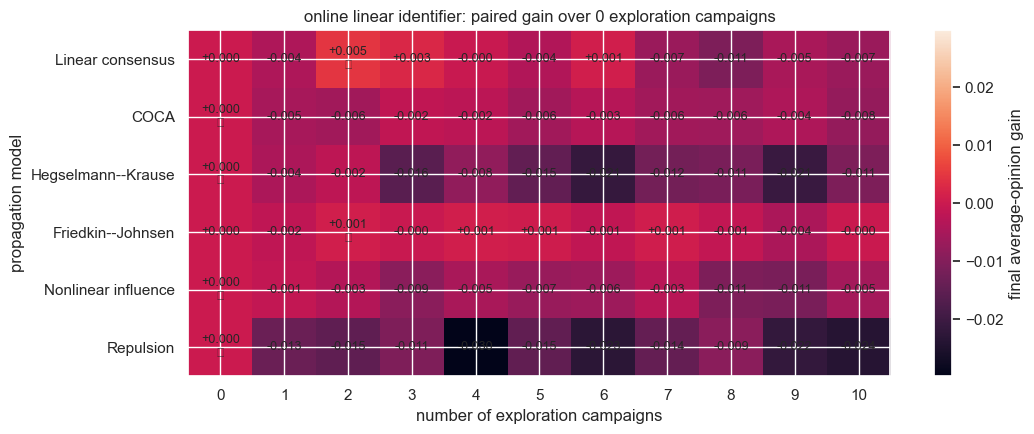

C:\Users\Chainsword\AppData\Local\Temp\ipykernel_34188\384703523.py:100: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  plt.tight_layout()
c:\Users\Chainsword\anaconda3\envs\phd_rl_algos\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


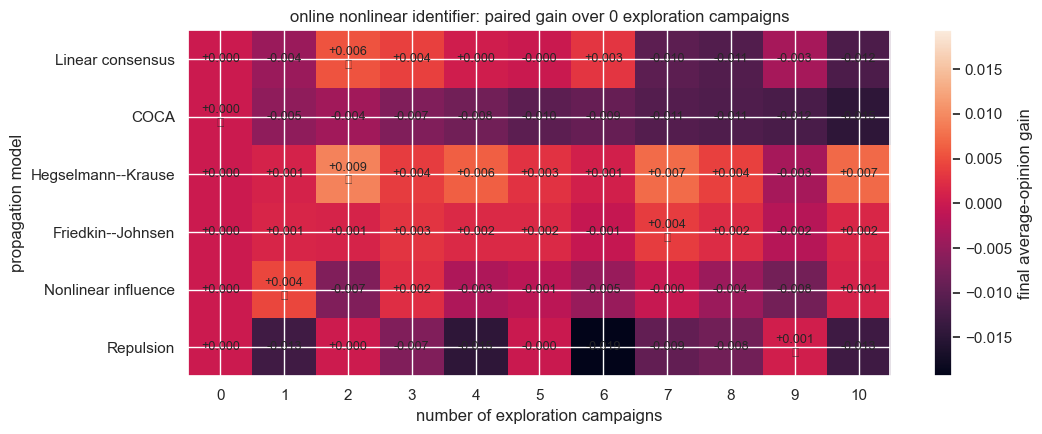

,dynamics,dynamics_label,model,model_label,exploration_campaigns_config,mean,std,count,sem,ci95
0,coca,COCA,online_linear_euler,online linear identifier,0,0.00000,0.00000,25,0.00000,0.00000
1,coca,COCA,online_linear_euler,online linear identifier,1,-0.00504,0.01409,25,0.00282,0.00552
2,coca,COCA,online_linear_euler,online linear identifier,2,-0.00599,0.01437,25,0.00287,0.00563
3,coca,COCA,online_linear_euler,online linear identifier,3,-0.00155,0.00890,25,0.00178,0.00349
4,coca,COCA,online_linear_euler,online linear identifier,4,-0.00221,0.01680,25,0.00336,0.00659
...,...,...,...,...,...,...,...,...,...,...
127,repulsion,Repulsion,online_nonlinear_lambda_mix,online nonlinear identifier,6,-0.01933,0.05939,25,0.01188,0.02328
128,repulsion,Repulsion,online_nonlinear_lambda_mix,online nonlinear identifier,7,-0.00945,0.03341,25,0.00668,0.01310
129,repulsion,Repulsion,online_nonlinear_lambda_mix,online nonlinear identifier,8,-0.00802,0.04769,25,0.00954,0.01870
130,repulsion,Repulsion,online_nonlinear_lambda_mix,online nonlinear identifier,9,0.00068,0.04606,25,0.00921,0.01805


In [14]:
# Pair every k with k=0 using the same dynamics, topology, initial state,
# and identifier. This is easier to interpret than raw final values:
# positive means that k exploration campaigns improved over no exploration.
pair_keys = [
    "dynamics",
    "dynamics_label",
    "topology_seed",
    "initial_seed",
    "trial_id",
    "model",
    "model_label",
]

zero = (
    summary_df[
        summary_df["exploration_campaigns_config"] == 0
    ][pair_keys + ["mean_end"]]
    .rename(columns={"mean_end": "mean_end_k0"})
)

paired_effect_df = summary_df.merge(
    zero,
    on=pair_keys,
    how="inner",
)
paired_effect_df["gain_vs_k0"] = (
    paired_effect_df["mean_end"]
    - paired_effect_df["mean_end_k0"]
)

paired_effect_summary = mean_ci95(
    paired_effect_df,
    "gain_vs_k0",
    [
        "dynamics",
        "dynamics_label",
        "model",
        "model_label",
        "exploration_campaigns_config",
    ],
)

def annotated_heatmap(
    table: pd.DataFrame,
    *,
    title: str,
    value_label: str,
    center_zero: bool = True,
) -> None:
    values = table.to_numpy(dtype=float)
    fig, ax = plt.subplots(
        figsize=(max(8, 0.72 * len(table.columns) + 3), 4.5)
    )
    if center_zero:
        vmax = float(np.nanmax(np.abs(values))) if values.size else 1.0
        vmax = max(vmax, 1e-12)
        im = ax.imshow(
            values,
            aspect="auto",
            vmin=-vmax,
            vmax=vmax,
        )
    else:
        im = ax.imshow(values, aspect="auto")

    ax.set_title(title)
    ax.set_xlabel("number of exploration campaigns")
    ax.set_ylabel("propagation model")
    ax.set_xticks(np.arange(len(table.columns)))
    ax.set_xticklabels(table.columns)
    ax.set_yticks(np.arange(len(table.index)))
    ax.set_yticklabels(table.index)

    for i in range(table.shape[0]):
        row = values[i]
        finite = np.isfinite(row)
        best_j = (
            int(np.nanargmax(row))
            if finite.any()
            else None
        )
        for j in range(table.shape[1]):
            val = values[i, j]
            if not np.isfinite(val):
                text = ""
            else:
                text = f"{val:+.3f}"
                if best_j == j:
                    text += "\n★"
            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=9,
            )

    fig.colorbar(im, ax=ax, label=value_label)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


for model in LEARNED_POLICIES:
    sub = paired_effect_summary[
        paired_effect_summary["model"] == model
    ]
    table = (
        sub.pivot(
            index="dynamics_label",
            columns="exploration_campaigns_config",
            values="mean",
        )
        .reindex(
            index=[
                DYNAMICS_LABELS[d]
                for d in ENABLED_DYNAMICS
            ],
            columns=EXPLORATION_CAMPAIGN_COUNTS,
        )
    )
    annotated_heatmap(
        table,
        title=(
            f"{POLICY_LABELS[model]}: paired gain over "
            "0 exploration campaigns"
        ),
        value_label="final average-opinion gain",
        center_zero=True,
    )

display(
    paired_effect_summary.sort_values(
        [
            "dynamics_label",
            "model_label",
            "exploration_campaigns_config",
        ]
    ).round(5)
)


## 2. Which exploration count is selected?

This plot isolates the final decision of interest instead of mixing it with fit diagnostics and trajectory plots.


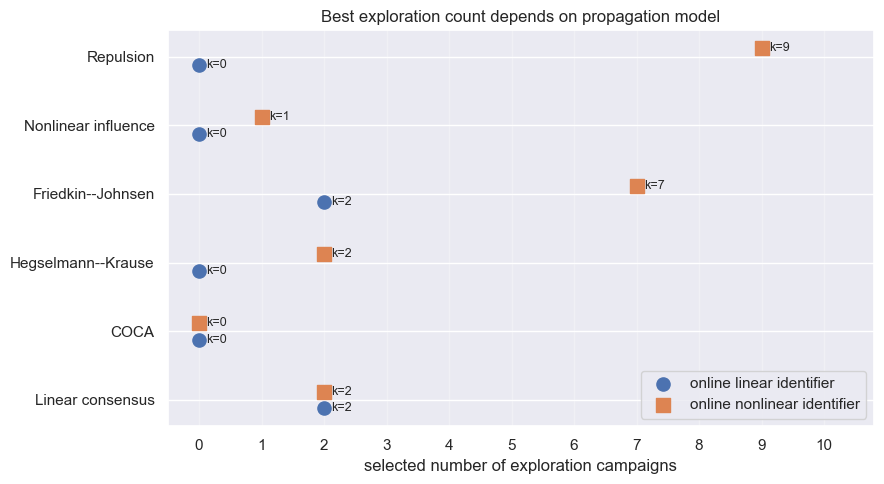

In [15]:
# Visual summary of the selected k for each propagation model.
fig, ax = plt.subplots(figsize=(9, 5))
y_labels = [
    DYNAMICS_LABELS[d]
    for d in ENABLED_DYNAMICS
]
y_pos = np.arange(len(y_labels), dtype=float)
offsets = {
    POLICY_LINEAR: -0.12,
    POLICY_NONLINEAR: 0.12,
}
markers = {
    POLICY_LINEAR: "o",
    POLICY_NONLINEAR: "s",
}

for model in LEARNED_POLICIES:
    sub = best_rows[
        best_rows["model"] == model
    ].set_index("dynamics_label")
    x = [
        float(
            sub.loc[label, "exploration_campaigns_config"]
        )
        for label in y_labels
    ]
    ax.scatter(
        x,
        y_pos + offsets[model],
        marker=markers[model],
        s=90,
        label=POLICY_LABELS[model],
    )
    for xi, yi in zip(x, y_pos + offsets[model]):
        ax.text(
            xi + 0.12,
            yi,
            f"k={int(xi)}",
            va="center",
            fontsize=9,
        )

ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels)
ax.set_xticks(EXPLORATION_CAMPAIGN_COUNTS)
ax.set_xlim(
    min(EXPLORATION_CAMPAIGN_COUNTS) - 0.5,
    max(EXPLORATION_CAMPAIGN_COUNTS) + 0.8,
)
ax.set_xlabel("selected number of exploration campaigns")
ax.set_title(
    "Best exploration count depends on propagation model"
)
ax.grid(True, axis="x", alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()
plt.close(fig)


## 3. How costly is choosing the wrong count?

These heatmaps show performance relative to the best observed \(k\) within each propagation-model/identifier pair. Values near zero indicate a broad, forgiving plateau; large negative values indicate that the choice of \(k\) matters.


C:\Users\Chainsword\AppData\Local\Temp\ipykernel_34188\384703523.py:100: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  plt.tight_layout()
c:\Users\Chainsword\anaconda3\envs\phd_rl_algos\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


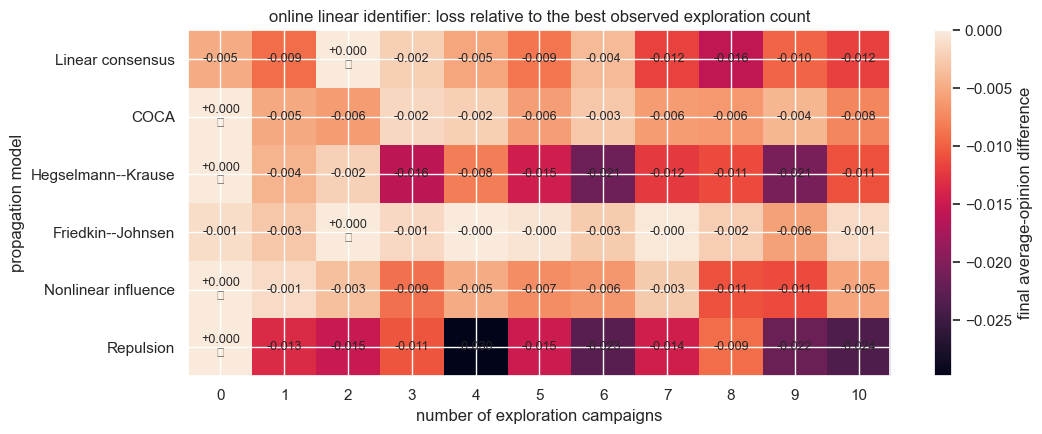

C:\Users\Chainsword\AppData\Local\Temp\ipykernel_34188\384703523.py:100: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  plt.tight_layout()
c:\Users\Chainsword\anaconda3\envs\phd_rl_algos\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


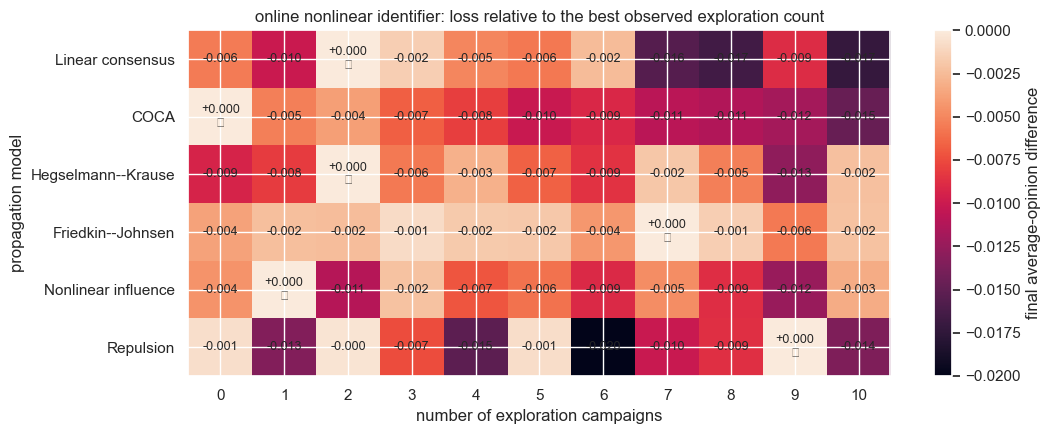

In [16]:
# Regret is expressed relative to the best observed k within each
# propagation-model/identifier combination. The best cell is 0; more
# negative cells indicate a more consequential choice of k.
best_means = (
    decision_summary.groupby(
        ["dynamics", "model"]
    )["mean"]
    .max()
    .rename("best_mean")
    .reset_index()
)
selection_sensitivity = decision_summary.merge(
    best_means,
    on=["dynamics", "model"],
    how="left",
)
selection_sensitivity["regret_vs_best_k"] = (
    selection_sensitivity["mean"]
    - selection_sensitivity["best_mean"]
)

for model in LEARNED_POLICIES:
    sub = selection_sensitivity[
        selection_sensitivity["model"] == model
    ]
    table = (
        sub.pivot(
            index="dynamics_label",
            columns="exploration_campaigns_config",
            values="regret_vs_best_k",
        )
        .reindex(
            index=[
                DYNAMICS_LABELS[d]
                for d in ENABLED_DYNAMICS
            ],
            columns=EXPLORATION_CAMPAIGN_COUNTS,
        )
    )
    annotated_heatmap(
        table,
        title=(
            f"{POLICY_LABELS[model]}: loss relative "
            "to the best observed exploration count"
        ),
        value_label="final average-opinion difference",
        center_zero=False,
    )

selection_sensitivity.to_csv(
    RESULTS_DIR / "exploration_selection_sensitivity.csv",
    index=False,
)


## 4. Raw exploration curves by propagation model

These are the conventional mean-with-95%-CI curves. They are useful for seeing the overall shape, but the paired and sensitivity plots above should be easier to interpret for model selection.


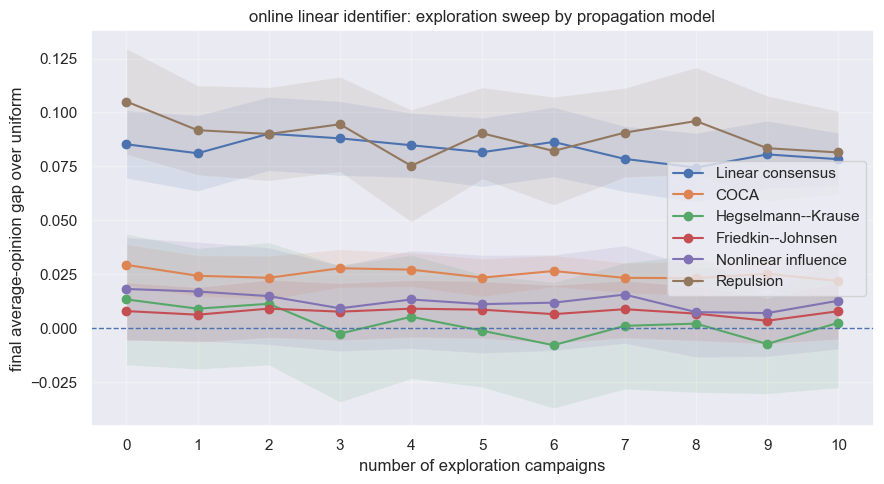

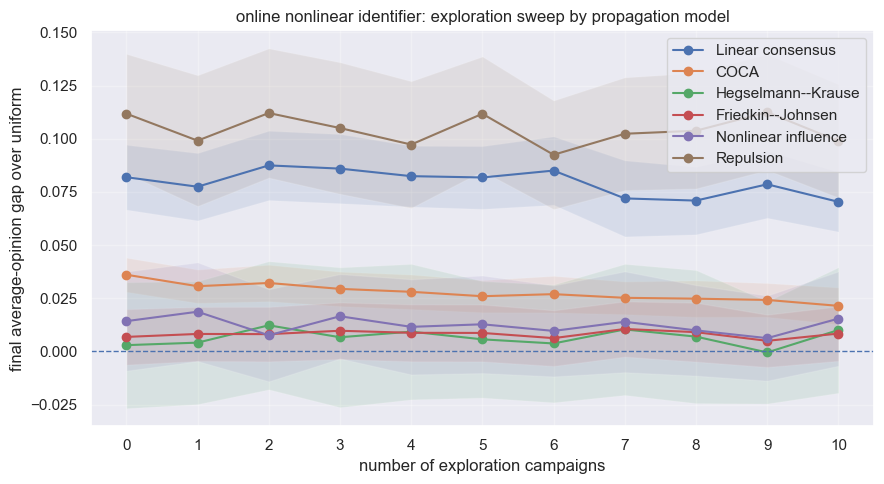

In [17]:
# Raw gap over uniform. One figure per identifier keeps the main comparison
# readable while showing propagation-model dependence.
for model in LEARNED_POLICIES:
    fig, ax = plt.subplots(figsize=(9, 5))
    sub_model = decision_summary[
        decision_summary["model"] == model
    ]
    for dynamics in ENABLED_DYNAMICS:
        sub = sub_model[
            sub_model["dynamics"] == dynamics
        ].sort_values("exploration_campaigns_config")
        x = sub["exploration_campaigns_config"].to_numpy(
            dtype=float
        )
        y = sub["mean"].to_numpy(dtype=float)
        e = sub["ci95"].to_numpy(dtype=float)
        ax.plot(
            x,
            y,
            marker="o",
            label=DYNAMICS_LABELS[dynamics],
        )
        ax.fill_between(
            x,
            y - e,
            y + e,
            alpha=0.12,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_xlabel("number of exploration campaigns")
    ax.set_ylabel("final average-opinion gap over uniform")
    ax.set_title(
        f"{POLICY_LABELS[model]}: exploration sweep "
        "by propagation model"
    )
    ax.set_xticks(EXPLORATION_CAMPAIGN_COUNTS)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()
    plt.close(fig)


# Optional diagnostics

Everything below is secondary to the decision plots above. Use these sections to understand *why* a particular exploration count performed well or poorly.


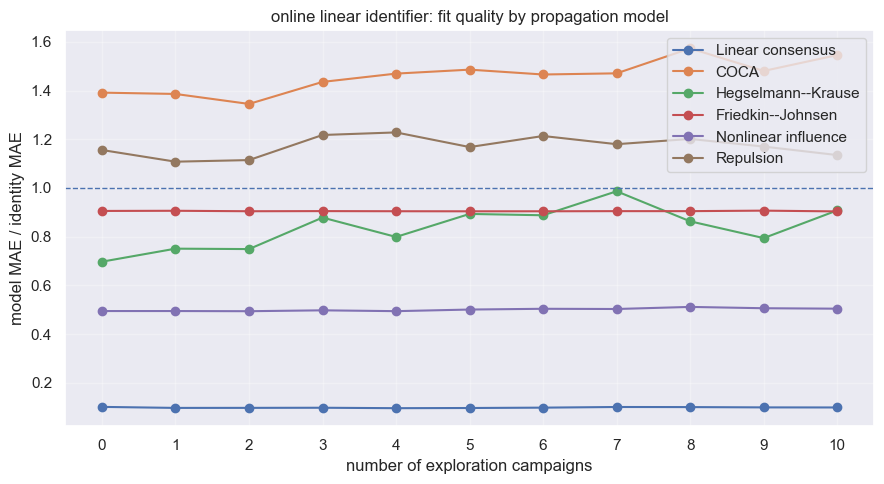

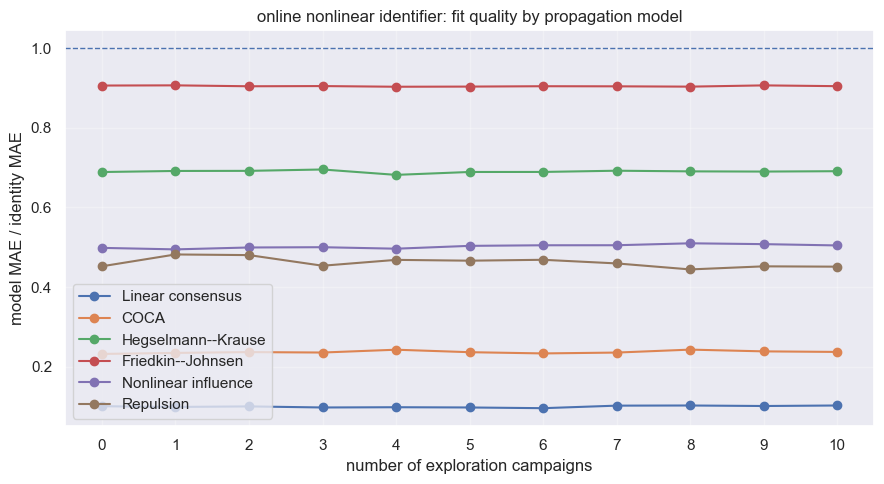

In [18]:
# Identifier fit quality is a secondary diagnostic. It becomes especially
# important when the true propagation law is nonlinear and the linear
# identifier is deliberately misspecified.
if not summary_df.empty:
    fit_summary = mean_ci95(
        summary_df.dropna(
            subset=["final_model_over_identity"]
        ),
        "final_model_over_identity",
        [
            "dynamics",
            "dynamics_label",
            "model",
            "model_label",
            "exploration_campaigns_config",
        ],
    )

    for model in LEARNED_POLICIES:
        fig, ax = plt.subplots(figsize=(9, 5))
        sub_model = fit_summary[
            fit_summary["model"] == model
        ]
        for dynamics in ENABLED_DYNAMICS:
            sub = sub_model[
                sub_model["dynamics"] == dynamics
            ].sort_values("exploration_campaigns_config")
            ax.plot(
                sub["exploration_campaigns_config"],
                sub["mean"],
                marker="o",
                label=DYNAMICS_LABELS[dynamics],
            )
        ax.axhline(1.0, linestyle="--", linewidth=1)
        ax.set_xlabel("number of exploration campaigns")
        ax.set_ylabel("model MAE / identity MAE")
        ax.set_title(
            f"{POLICY_LABELS[model]}: fit quality "
            "by propagation model"
        )
        ax.set_xticks(EXPLORATION_CAMPAIGN_COUNTS)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")
        plt.tight_layout()
        plt.show()
        plt.close(fig)


## Best and worst average-opinion trajectories

For each propagation model and identifier, only the exploration counts with the
best and worst mean final performance are shown. Figures are closed immediately
after display to avoid accumulating Matplotlib objects in memory.


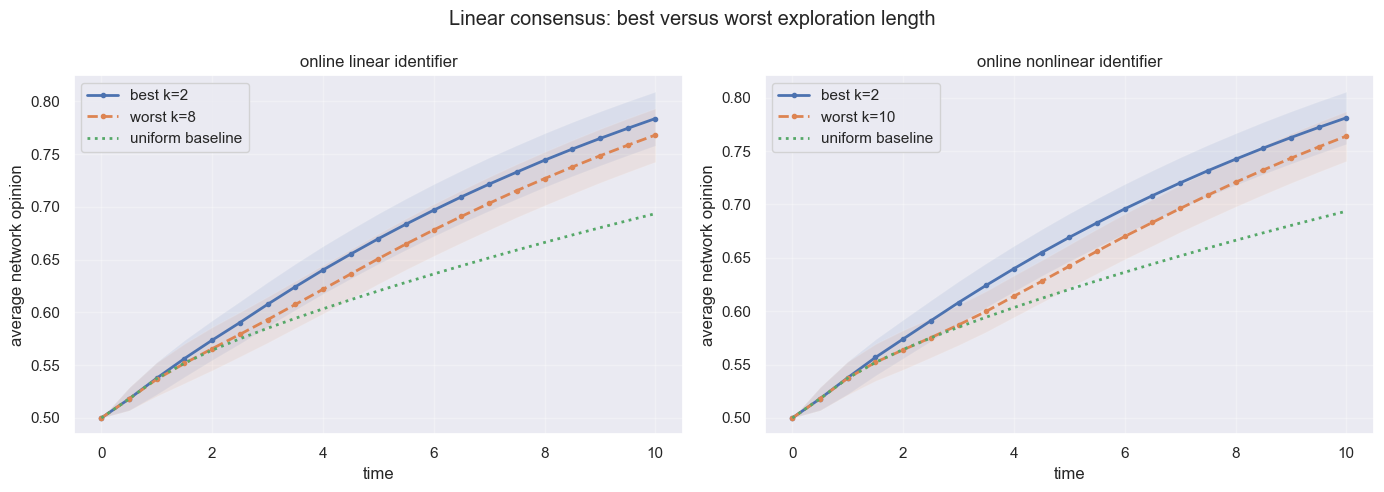

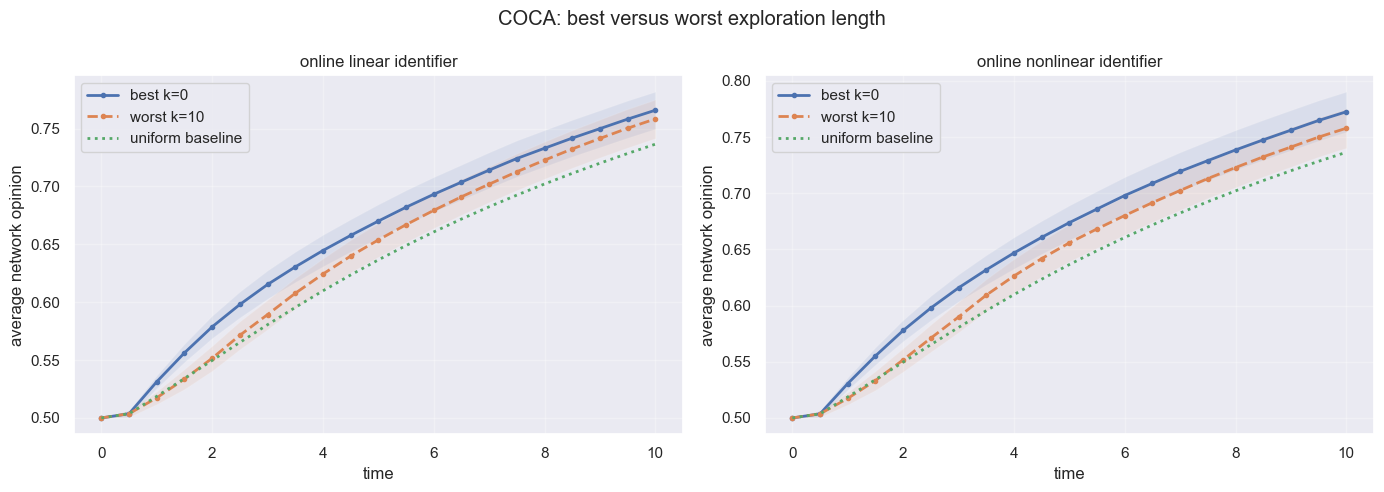

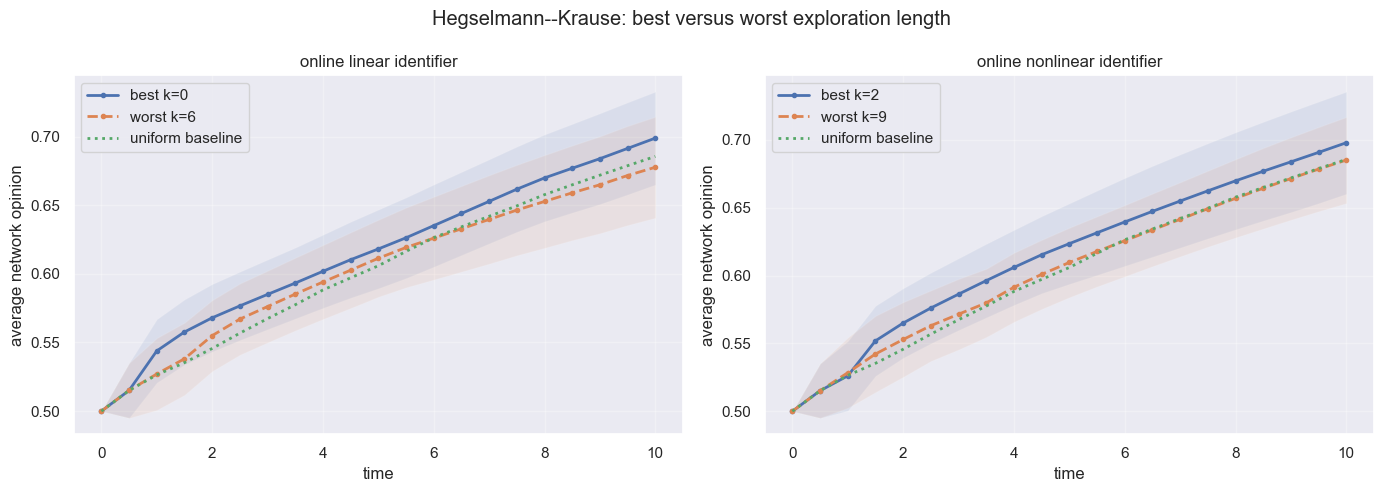

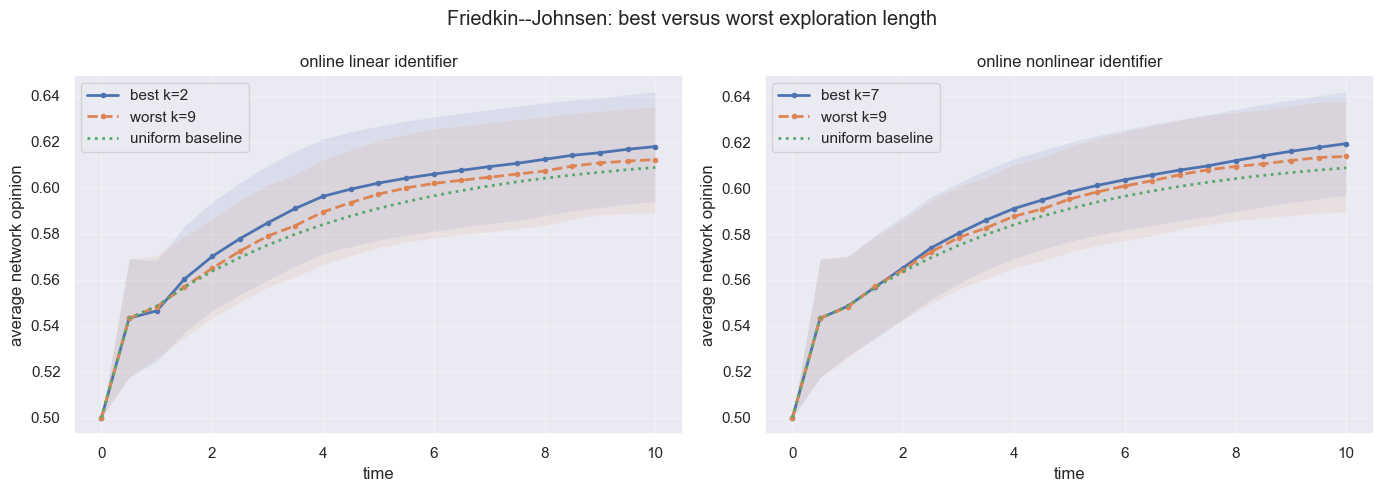

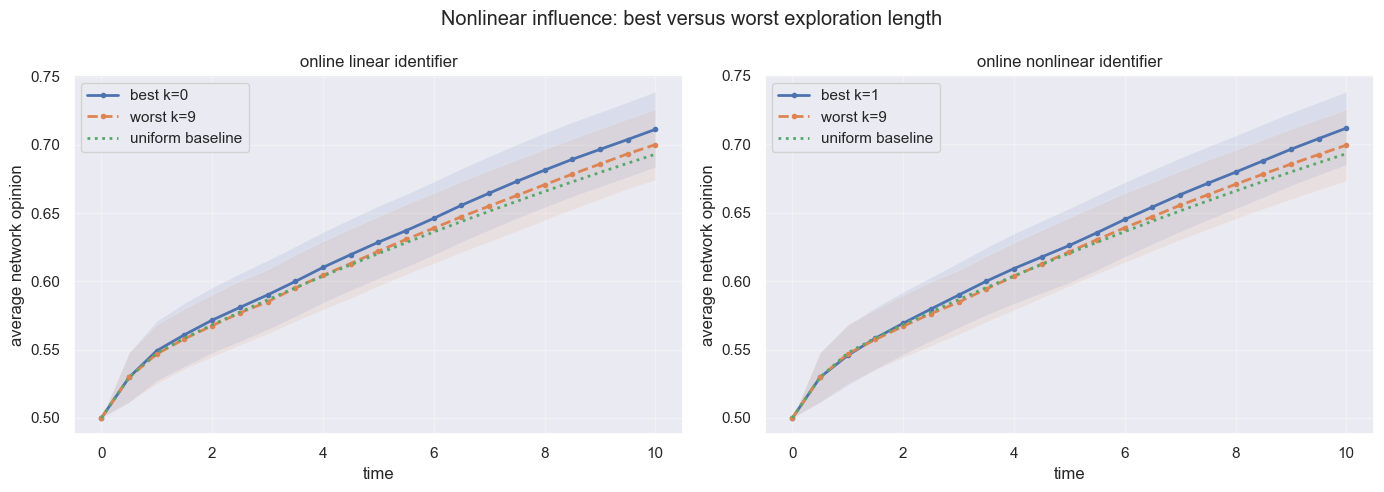

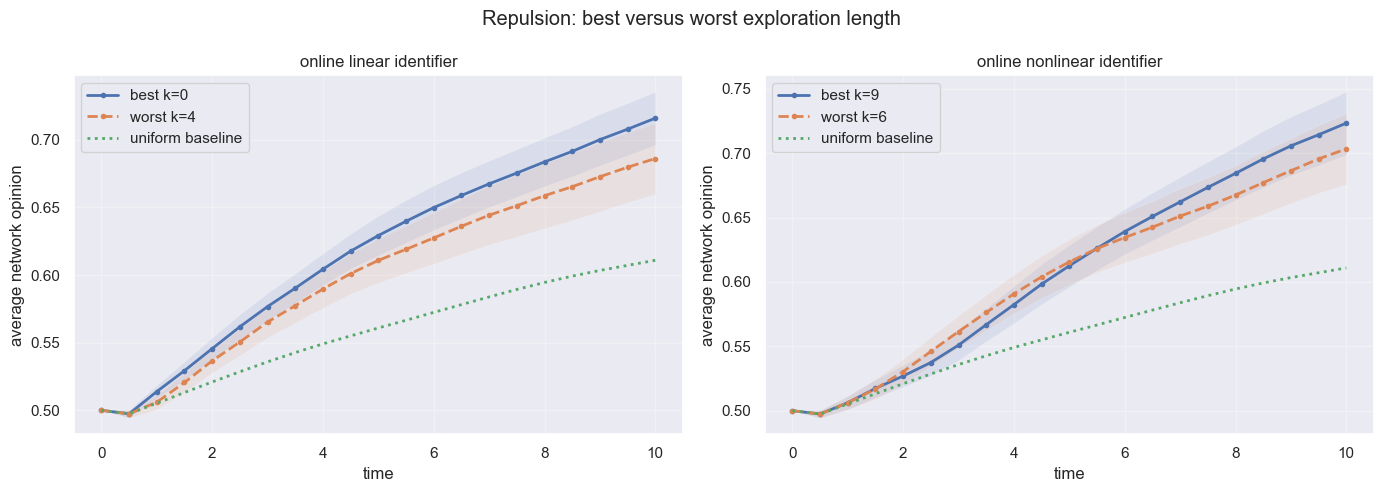

,dynamics,dynamics_label,model,model_label,best_k,worst_k,best_mean_gap,worst_mean_gap
0,laplacian,Linear consensus,online_linear_euler,online linear identifier,2,8,0.090135,0.074472
1,laplacian,Linear consensus,online_nonlinear_lambda_mix,online nonlinear identifier,2,10,0.087481,0.070345
2,coca,COCA,online_linear_euler,online linear identifier,0,10,0.029337,0.021834
3,coca,COCA,online_nonlinear_lambda_mix,online nonlinear identifier,0,10,0.036059,0.021424
4,hegselmannkrause,Hegselmann--Krause,online_linear_euler,online linear identifier,0,6,0.013325,-0.007891
5,hegselmannkrause,Hegselmann--Krause,online_nonlinear_lambda_mix,online nonlinear identifier,2,9,0.012271,-0.000490
6,friedkinjohnsen,Friedkin--Johnsen,online_linear_euler,online linear identifier,2,9,0.009060,0.003446
7,friedkinjohnsen,Friedkin--Johnsen,online_nonlinear_lambda_mix,online nonlinear identifier,7,9,0.010542,0.004972
8,nonlinearinfluence,Nonlinear influence,online_linear_euler,online linear identifier,0,9,0.018170,0.006988
9,nonlinearinfluence,Nonlinear influence,online_nonlinear_lambda_mix,online nonlinear identifier,1,9,0.018658,0.006230


In [19]:

selection_rows: List[Dict[str, Any]] = []

for dynamics in ENABLED_DYNAMICS:
    model_summaries = {}
    for model in LEARNED_POLICIES:
        sub = decision_summary[
            (decision_summary["dynamics"] == dynamics)
            & (decision_summary["model"] == model)
        ].sort_values(
            ["mean", "exploration_campaigns_config"],
            ascending=[False, True],
        )
        if sub.empty:
            continue
        best_row = sub.iloc[0]
        worst_row = sub.sort_values(
            ["mean", "exploration_campaigns_config"],
            ascending=[True, True],
        ).iloc[0]
        model_summaries[model] = {
            "best_k": int(best_row["exploration_campaigns_config"]),
            "worst_k": int(worst_row["exploration_campaigns_config"]),
            "best_mean_gap": float(best_row["mean"]),
            "worst_mean_gap": float(worst_row["mean"]),
        }
        selection_rows.append(
            {
                "dynamics": dynamics,
                "dynamics_label": DYNAMICS_LABELS[dynamics],
                "model": model,
                "model_label": POLICY_LABELS[model],
                **model_summaries[model],
            }
        )

    if not model_summaries:
        continue

    fig, axes = plt.subplots(
        1,
        len(model_summaries),
        figsize=(7 * len(model_summaries), 5),
        squeeze=False,
    )

    for ax, (model, selected) in zip(axes[0], model_summaries.items()):
        best_k = selected["best_k"]
        worst_k = selected["worst_k"]

        for exploration_count, curve_label, line_style in [
            (best_k, f"best k={best_k}", "-"),
            (worst_k, f"worst k={worst_k}", "--"),
        ]:
            sub = trajectory_df[
                (trajectory_df["dynamics"] == dynamics)
                & (trajectory_df["policy"] == model)
                & (
                    trajectory_df["exploration_campaigns_config"]
                    == exploration_count
                )
            ]
            if sub.empty:
                continue

            grouped = sub.groupby("time")["mean_opinion"]
            mean = grouped.mean()
            count = grouped.count()
            sem = (
                grouped.std(ddof=1)
                / np.sqrt(count.clip(lower=1))
            ).fillna(0.0)

            x = mean.index.to_numpy(dtype=float)
            y = mean.to_numpy(dtype=float)
            e = 1.96 * sem.to_numpy(dtype=float)

            ax.plot(
                x,
                y,
                linestyle=line_style,
                linewidth=2,
                marker="o",
                markersize=3,
                label=curve_label,
            )
            ax.fill_between(
                x,
                y - e,
                y + e,
                alpha=0.10,
            )

        # Uniform is independent of k. Select one condition to avoid plotting
        # duplicate baseline rows stored for every exploration count.
        uniform_sub = trajectory_df[
            (trajectory_df["dynamics"] == dynamics)
            & (trajectory_df["policy"] == POLICY_UNIFORM)
            & (
                trajectory_df["exploration_campaigns_config"]
                == best_k
            )
        ]
        if not uniform_sub.empty:
            uniform_mean = (
                uniform_sub.groupby("time")["mean_opinion"]
                .mean()
            )
            ax.plot(
                uniform_mean.index.to_numpy(dtype=float),
                uniform_mean.to_numpy(dtype=float),
                linestyle=":",
                linewidth=2,
                label="uniform baseline",
            )

        ax.set_title(POLICY_LABELS[model])
        ax.set_xlabel("time")
        ax.set_ylabel("average network opinion")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")

    fig.suptitle(
        f"{DYNAMICS_LABELS[dynamics]}: best versus worst exploration length"
    )
    fig.tight_layout()
    plt.show()
    plt.close(fig)

best_worst_trajectory_table = pd.DataFrame(selection_rows)
best_worst_trajectory_table.to_csv(
    RESULTS_DIR / "best_worst_trajectory_selection.csv",
    index=False,
)
display(best_worst_trajectory_table)


## Extending the propagation-model sweep

To add a propagation model, enable its entry in `DYNAMICS_SPECS`. The run loop, tables, and plots will include it automatically.

Important interpretation notes:

- `laplacian` and `degroot` are aliases in the current environment, so they should not both be included.
- The linear identifier is correctly specified only for linear consensus. Under COCA, HK, FJ, nonlinear influence, or repulsion, it is intentionally a misspecified baseline.
- Graph-centrality recovery and graph-weighted target error are secondary diagnostics for nonlinear models; final average opinion and paired performance against uniform remain the primary metrics.
- Repulsion can fail to converge or produce qualitatively different behavior, so enable it as a separate robustness study rather than silently mixing it into the main paper result.
